# Figure-1 Training Curve Plots — Weights & Biases export

Reads the per-seed CSVs saved in `results/training/` (from
`training_data_extraction_wandb.ipynb`) and produces journal-ready training
curves: mean +/- error across seeds.

Panels:

- **A.** Training loss (total = actor + critic)
- **B.** Training return (raw per-episode, not the rolling average)
- **C.** Training consumption
- **D.** Training L2 distance

More plotting cells can be added below this one.


## 1. Imports and data loading

Globs every `*_training.csv` in `results/training/` and parses the seed from the filename.

In [1]:
import re
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# ── Canonical condition colour scheme (used across all experiments) ─────
C_NORMAL = "#1b4965"   # blue   — baseline / normal / no-clip
C_OVER   = "#c1121f"   # red    — over-eating
C_UNDER  = "#e07a00"   # orange — under-eating
C_TARGET = "green"     # target zone / target marker
# C_EAT    = "#5c3a21"   # dark brown — eating instances (uniform across all figures)
C_EAT    = "#4F46E5" 
# ── Canonical sleep-shading (Fig 2 scheme; reused everywhere incl. Fig 5) ─
def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)
SLEEP_COLOR = lighten("navy", 0.88)   # solid light-navy sleep fill (no alpha)

# ── Central figure-save helper: one section folder per figure ───────────
PLOTS_ROOT   = Path("plots")
SAVE_FORMATS = ("png", "pdf", "svg", "eps")
def save_fig(fig, section, name, dpi=300):
    """Save `fig` as plots/<section>/<name>.{png,pdf,svg,eps}."""
    d = PLOTS_ROOT / section
    d.mkdir(parents=True, exist_ok=True)
    for ext in SAVE_FORMATS:
        fig.savefig(d / f"{name}.{ext}", dpi=dpi, bbox_inches="tight", pad_inches=0.02,)
    print(f"saved {section}/{name}.[{'|'.join(SAVE_FORMATS)}]")

# ── Paths ───────────────────────────────────────────────────────────────
DATA_DIR = Path("results") / "training_data"
OUT_DIR  = Path("plots") / "plots_training"
OUT_DIR.mkdir(parents=True, exist_ok=True)

X_COL = "_step"   # episode counter logged by wandb


def load_seed_csvs(data_dir):
    """Load every Run_Seed*_training.csv into {seed: DataFrame}.

    Adds a derived 'train/total_loss' = actor_loss + critic_loss column.
    """
    files = sorted(glob(str(data_dir / "*_training.csv")))
    if not files:
        raise FileNotFoundError(
            f"No '*_training.csv' files in {data_dir}. "
            f"Run the extraction notebook first."
        )
    data = {}
    for f in files:
        m = re.search(r"Seed(\d+)", Path(f).name)
        seed = int(m.group(1)) if m else Path(f).stem
        df = pd.read_csv(f)
        if {"train/actor_loss", "train/critic_loss"}.issubset(df.columns):
            df["train/total_loss"] = df["train/actor_loss"] + df["train/critic_loss"]
        data[seed] = df
    print(f"Loaded {len(data)} seed(s): {sorted(data.keys())}")
    return data


def aggregate(data, metric, x_col=X_COL, err="sem"):
    """Align all seeds on x_col and return (x, mean, error) across seeds.

    err : 'sem' (standard error of the mean) or 'std' (standard deviation).
    """
    series = {}
    for seed, df in data.items():
        if metric not in df.columns:
            continue
        s = df[[x_col, metric]].dropna(subset=[x_col]).set_index(x_col)[metric]
        s = s[~s.index.duplicated(keep="last")]
        series[seed] = s
    if not series:
        raise KeyError(f"Metric '{metric}' not found in any seed CSV.")

    wide = pd.DataFrame(series).sort_index()   # index = step, columns = seeds
    mean = wide.mean(axis=1, skipna=True)
    std  = wide.std(axis=1, skipna=True, ddof=1)
    n    = wide.notna().sum(axis=1)
    error = std / np.sqrt(n) if err == "sem" else std
    error = error.fillna(0.0)                   # single seed -> zero band
    return wide.index.values, mean.values, error.values


data = load_seed_csvs(DATA_DIR)


Loaded 10 seed(s): [0, 7, 27, 42, 64, 100, 107, 1997, 2003, 2026]


## 2. Training curves (Panels A-D)

All font sizes and styling are controlled by the `rcParams` block at the top of
this cell.

**Y-axis zoom:** the first few episodes contain a large transient (loss/return
spike) that flattens the rest of the curve. `Y_CLIP=True` clips each panel's
y-limits to the `Y_CLIP_PERCENTILE` range of the mean±error, so the settled
dynamics and the error bands are visible. To show the full range including the
spike, set `Y_CLIP=False`, or override a single panel via `Y_LIMITS`.


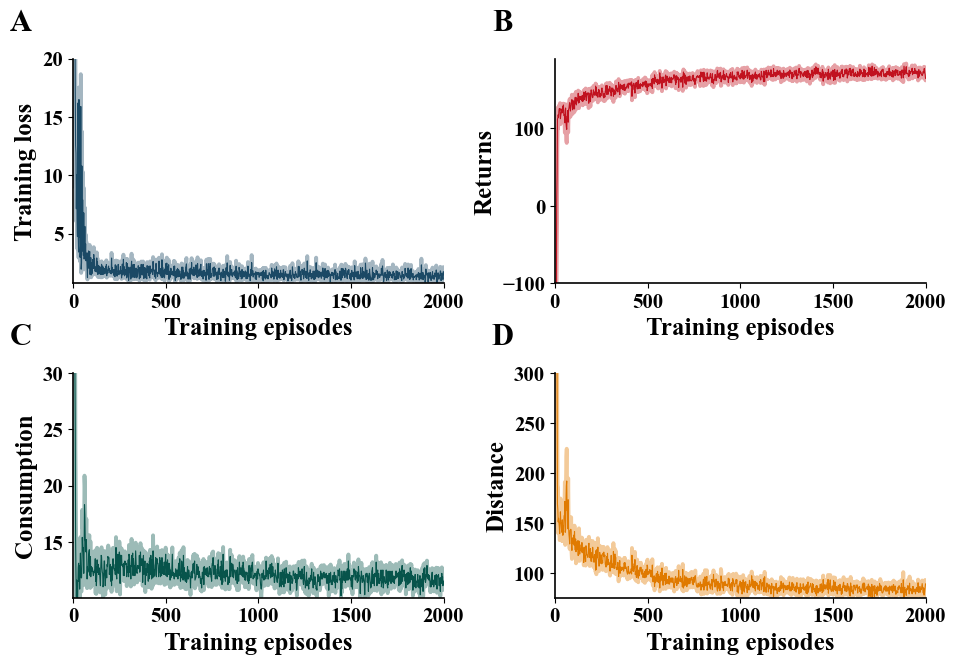

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE STYLE — all font sizes / styling controlled here
# ══════════════════════════════════════════════════════════════════════
#  FIGURE STYLE — all font sizes / styling controlled here
# ══════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    18,
    "axes.labelsize":    18,
    "xtick.labelsize":   15,
    "ytick.labelsize":   15,
    "legend.fontsize":   15,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    # ── bold everything ──────────────────────────────
    "font.weight":       "bold",   # tick labels, legend, general text
    "axes.labelweight":  "bold",   # x / y axis labels
    "axes.titleweight":  "bold",   # subplot titles
    "mathtext.default":  "bf",     # bold math text (the ± in the legend)
    # ── no grids, no top/right spines (applies to every 2-D axis) ─────
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

PANEL_LABEL_SIZE = 22     # size of the A, B, C, D labels
BAND_LIGHTEN     = 0.60   # 0 = full colour band, 1 = white
ERROR            = "sem"  # 'sem' or 'std'

# ── colors: [loss, rewards, consumption, distance] ─────────────────────
COLORS = ["#1b4965", "#c1121f", "#07544b", "#e07a00"]
c_loss, c_rewards, c_consumption, c_distance = COLORS

import matplotlib.colors as mcolors
def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

fig, ((ax_loss, ax_rewards),
      (ax_consumption, ax_distance)) = plt.subplots(2, 2, figsize=(11, 7))
fig.subplots_adjust(wspace=0.3, hspace=0.4) 

# ── A: Total loss (actor + critic) ─────────────────────────────────────
x, mean, err = aggregate(data, "train/total_loss", err=ERROR)
ax_loss.fill_between(x, mean - err, mean + err, color=lighten(c_loss, BAND_LIGHTEN), linewidth=2.75)
ax_loss.plot(x, mean, color=c_loss, linewidth = 0.8)
ax_loss.set_xlabel("Training episodes")
ax_loss.set_ylabel("Training loss")
ax_loss.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_loss.set_ylim(np.nanpercentile(mean - err, 1) * 0.9, np.nanpercentile(mean + err, 99) * 1.1)
ax_loss.set_ylim(np.nanpercentile(mean - err, 1) * 0.9, 20)
ax_loss.spines[["top", "right"]].set_visible(False)
ax_loss.text(-0.17, 1.22, "A", transform=ax_loss.transAxes,
             fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

# ── B: Return ──────────────────────────────────────────────────────────
x, mean, err = aggregate(data, "train/reward", err=ERROR)
ax_rewards.fill_between(x, mean - err, mean + err, color=lighten(c_rewards, BAND_LIGHTEN), linewidth=2.75)
ax_rewards.plot(x, mean, color=c_rewards, linewidth =0.8)
ax_rewards.set_xlabel("Training episodes")
ax_rewards.set_ylabel("Returns")
ax_rewards.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_rewards.set_ylim(np.nanpercentile(mean - err, 1), np.nanpercentile(mean + err, 99) * 1.05)
ax_rewards.set_ylim(-100, np.nanpercentile(mean + err, 99) * 1.05)
ax_rewards.spines[["top", "right"]].set_visible(False)
ax_rewards.text(-0.17, 1.22, "B", transform=ax_rewards.transAxes,
                fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

# ── C: Consumption ─────────────────────────────────────────────────────
x, mean, err = aggregate(data, "train/consumption", err=ERROR)
ax_consumption.fill_between(x, mean - err, mean + err, color=lighten(c_consumption, BAND_LIGHTEN), linewidth=2.75)
ax_consumption.plot(x, mean, color=c_consumption, linewidth = 0.8)
ax_consumption.set_xlabel("Training episodes")
ax_consumption.set_ylabel("Consumption")
ax_consumption.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_consumption.set_ylim(np.nanpercentile(mean - err, 1), np.nanpercentile(mean + err, 99))
ax_consumption.set_ylim(np.nanpercentile(mean - err, 1),30)
ax_consumption.spines[["top", "right"]].set_visible(False)
ax_consumption.text(-0.17, 1.22, "C", transform=ax_consumption.transAxes,
                    fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

# ── D: L2 distance ─────────────────────────────────────────────────────
x, mean, err = aggregate(data, "train/distance", err=ERROR)
ax_distance.fill_between(x, mean - err, mean + err, color=lighten(c_distance, BAND_LIGHTEN), linewidth=2.75)
ax_distance.plot(x, mean, color=c_distance, linewidth = 0.8)
ax_distance.set_xlabel("Training episodes")
ax_distance.set_ylabel("Distance")
ax_distance.set_xlim(x.min() - 0.01 * (x.max() - x.min()), x.max())
# ax_distance.set_ylim(np.nanpercentile(mean - err, 1), np.nanpercentile(mean + err, 99) * 1.1)
ax_distance.set_ylim(np.nanpercentile(mean - err, 1), 300)
ax_distance.spines[["top", "right"]].set_visible(False)
ax_distance.text(-0.17, 1.22, "D", transform=ax_distance.transAxes,
                 fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")


for axes in [ax_consumption, ax_distance, ax_loss, ax_rewards]:
    axes.set_xlim(0, 2000)


# fig.tight_layout(rect=[0, 0, 1, 0.96], w_pad=3.0, h_pad=3.0)

# ── save (300 dpi, png/pdf/svg/eps) ────────────────────────────────────
# save_fig(fig, "fig1_training", "fig1_training_curves")

plt.show()

# Figure-2 — Inference of the trained model

Reads the inference data saved by `infer_run.ipynb` in
`results/plots_inference_normal/` and reproduces two journal figures.
**Note:** this inference is for a single trained model (seed 0, best checkpoint,
200 inference episodes); "averaged over inference runs" = averaged over those
200 episodes.

- **2.1** 2x2 grid: reward, distance, signed error (per-step line + SEM band,
  averaged over the 200 runs) and calories consumed per day (bar).
- **2.2** 3x1 grid: one representative episode's raw-unit traces for glucose,
  free fatty acids, and small peptides.

Main figures are saved to the root `plots/` folder.


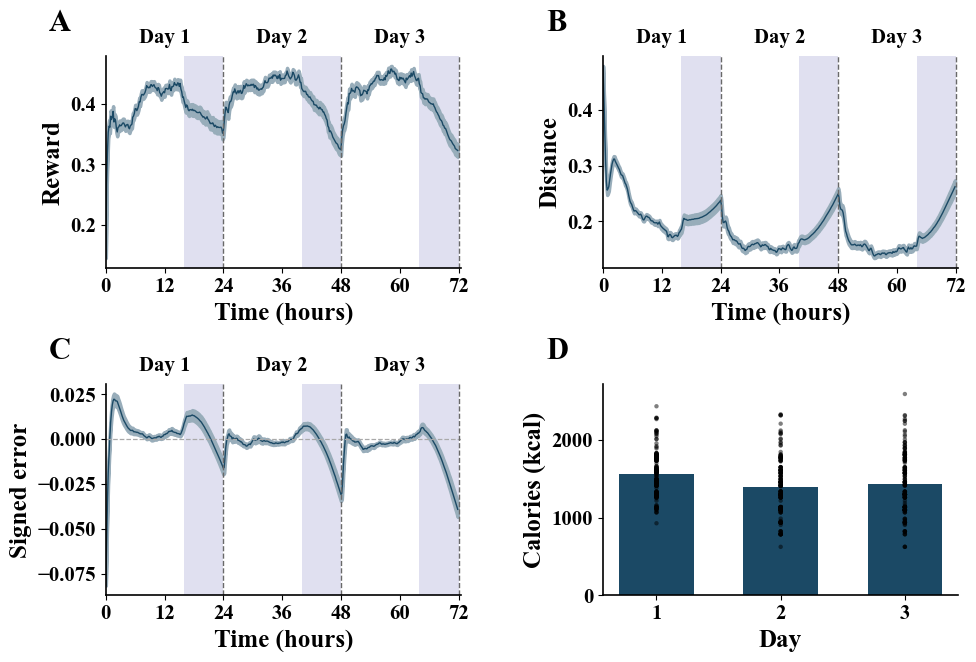

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 2.1 — reward / distance / signed error (lines) + calories (bar)
# ══════════════════════════════════════════════════════════════════════
import pickle
import matplotlib.colors as mcolors

INF_DIR   = Path("results") / "plots_inference_normal"
PLOTS_DIR = Path("plots")/ "plots_inference"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

perstep = pd.read_pickle(INF_DIR / "inference_perstep_stats.pkl")
cal_day = pd.read_pickle(INF_DIR / "calories_per_day.pkl")

# ── time axis ─────────────────────────────────────────────────────────
AWAKE_STEPS, SLEEP_STEPS = 96, 48
AWAKE_HRS,   SLEEP_HRS   = 16, 8
STEPS_PER_HOUR = AWAKE_STEPS / AWAKE_HRS
TOTAL_HOURS    = len(perstep) / STEPS_PER_HOUR

def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount,
            g + (1 - g) * amount,
            b + (1 - b) * amount)


def shade_sleep(ax, is_awake, scale=STEPS_PER_HOUR, first_label=True):
    a = np.asarray(is_awake).astype(bool)
    in_sleep, start, first = False, 0, first_label

    for t, awake in enumerate(a):
        if not awake and not in_sleep:
            in_sleep, start = True, t
        elif awake and in_sleep:
            ax.axvspan(start/scale, t/scale,
                       color=SLEEP_COLOR, lw=0, zorder=0,
                       label="Sleep" if first else None)
            first = False
            in_sleep = False

    if in_sleep:
        ax.axvspan(start/scale, len(a)/scale,
                   color=SLEEP_COLOR, lw=0, zorder=0,
                   label="Sleep" if first else None)

# ── add day labels ────────────────────────────────────────────────────
def add_day_labels(ax):
    day_centers = [12, 36, 60]
    day_labels  = ["Day 1", "Day 2", "Day 3"]

    for x, lab in zip(day_centers, day_labels):
        ax.text(
            x, 1.04, lab,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=15,
            fontweight="bold",
        )

    # day boundaries
    for x in [24, 48, 72]:
        ax.axvline(x, color="dimgray", ls="--", lw=1.0, alpha=1.0)

PANEL_LABEL_SIZE = 22
BAND_LIGHTEN     = 0.55
LINE_W           = 1.0

# Fig 2 = normal model → all panels use the normal (blue) condition colour
c_reward = c_distance = c_signed = c_cal = C_NORMAL

hours    = perstep["step"].values / STEPS_PER_HOUR
is_awake = perstep["is_awake"].values

HOUR_TICKS = np.arange(0, TOTAL_HOURS + 1, 12)

fig, ((ax_reward, ax_distance),
      (ax_signed, ax_cal)) = plt.subplots(2, 2, figsize=(11, 7))

fig.subplots_adjust(wspace=0.4, hspace=0.55)

# ──────────────────────────────────────────────────────────────────────
# A. Reward
# ──────────────────────────────────────────────────────────────────────
mu = perstep["reward_mean"].values
se = perstep["reward_sem"].values

shade_sleep(ax_reward, is_awake)
ax_reward.fill_between(hours, mu-se, mu+se,
                       color=lighten(c_reward, BAND_LIGHTEN),
                       lw=2.5, zorder=1,)
ax_reward.plot(hours, mu, color=c_reward, lw=LINE_W, zorder=2)

ax_reward.set_xlabel("Time (hours)")
ax_reward.set_ylabel("Reward")
ax_reward.set_xlim(0, TOTAL_HOURS)
ax_reward.set_xticks(HOUR_TICKS)
ax_reward.spines[["top", "right"]].set_visible(False)

add_day_labels(ax_reward)

ax_reward.text(-0.16, 1.22, "A",
               transform=ax_reward.transAxes,
               fontsize=PANEL_LABEL_SIZE,
               fontweight="bold",
               va="top", ha="left")

# ──────────────────────────────────────────────────────────────────────
# B. Distance
# ──────────────────────────────────────────────────────────────────────
mu = perstep["distance_mean"].values
se = perstep["distance_sem"].values

shade_sleep(ax_distance, is_awake)
ax_distance.fill_between(hours, mu-se, mu+se,
                         color=lighten(c_distance, BAND_LIGHTEN),
                         lw=2.5, zorder=1)
ax_distance.plot(hours, mu, color=c_distance, lw=LINE_W, zorder=2)

ax_distance.set_xlabel("Time (hours)")
ax_distance.set_ylabel("Distance")
ax_distance.set_xlim(0, TOTAL_HOURS)
ax_distance.set_xticks(HOUR_TICKS)
ax_distance.spines[["top", "right"]].set_visible(False)

add_day_labels(ax_distance)

ax_distance.text(-0.16, 1.22, "B",
                 transform=ax_distance.transAxes,
                 fontsize=PANEL_LABEL_SIZE,
                 fontweight="bold",
                 va="top", ha="left")

# ──────────────────────────────────────────────────────────────────────
# C. Signed error
# ──────────────────────────────────────────────────────────────────────
mu = perstep["signed_error_mean"].values
se = perstep["signed_error_sem"].values

shade_sleep(ax_signed, is_awake)
ax_signed.fill_between(hours, mu-se, mu+se,
                       color=lighten(c_signed, BAND_LIGHTEN),
                       lw=2.5, zorder=1)
ax_signed.plot(hours, mu, color=c_signed, lw=LINE_W, zorder=2)

ax_signed.axhline(0, color="darkgrey", lw=0.9, ls="--", alpha=1.0)

ax_signed.set_xlabel("Time (hours)")
ax_signed.set_ylabel("Signed error")
ax_signed.set_xlim(0, TOTAL_HOURS)
ax_signed.set_xticks(HOUR_TICKS)
ax_signed.spines[["top", "right"]].set_visible(False)

add_day_labels(ax_signed)

ax_signed.text(-0.16, 1.22, "C",
               transform=ax_signed.transAxes,
               fontsize=PANEL_LABEL_SIZE,
               fontweight="bold",
               va="top", ha="left")


# ──────────────────────────────────────────────────────────────────────
# D. Calories
# ──────────────────────────────────────────────────────────────────────
cal_ep = pd.read_pickle(INF_DIR / "calories_per_episode.pkl")   # (episodes, days)
days   = cal_day["day"].values

ax_cal.bar(days,
           cal_day["mean_kcal"].values,
        #    yerr=cal_day["sem_kcal"].values,
           color=c_cal,
           width=0.6,
           capsize=5,
           error_kw=dict(ecolor="black", elinewidth=1.3),
           zorder=2)

# all per-episode data points as jittered scatter
rng = np.random.default_rng(0)
for k, col in enumerate(cal_ep.columns):
    xj = days[k] * np.ones(len(cal_ep))#+ rng.uniform(-0.18, 0.18, size=len(cal_ep))
    ax_cal.scatter(xj, cal_ep[col].values, s=10, color="black",
                   alpha=0.50, edgecolors="none", zorder=3)

ax_cal.set_xlabel("Day")
ax_cal.set_ylabel("Calories (kcal)")
ax_cal.set_xticks(days)
# ax_cal.set_xticklabels([f"Day-{d}" for d in days])
ax_cal.spines[["top", "right"]].set_visible(False)

ax_cal.text(-0.16, 1.22, "D",
            transform=ax_cal.transAxes,
            fontsize=PANEL_LABEL_SIZE,
            fontweight="bold",
            va="top", ha="left")

for axes in [ax_reward, ax_distance, ax_signed]:
    axes.set_xlim(0,72.5)
# ──────────────────────────────────────────────────────────────────────
# Save
# ──────────────────────────────────────────────────────────────────────
# save_fig(fig, "fig2_normal_inference", "fig2_1_normal_inference_summary")

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig2_normal_inference/baseline_nutrient_trajectories.[png|pdf|svg|eps]


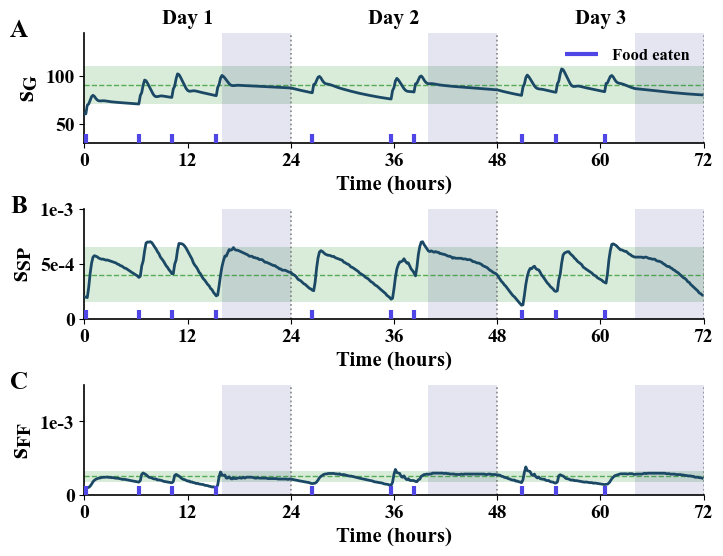

In [4]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 2.2 — representative episode, raw-unit nutrient traces (3 rows)
#  inference-style alpha shading; green target zone; raw units only
#  + eating events drawn as bottom "|" ticks (same style as Fig 4)
# ══════════════════════════════════════════════════════════════════════
from matplotlib.ticker import FuncFormatter
from matplotlib.transforms import blended_transform_factory

plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         14,
    "axes.titlesize":    16,
    "axes.labelsize":    16,
    "xtick.labelsize":   14,
    "ytick.labelsize":   14,
    "legend.fontsize":   14,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    # ── bold everything ──────────────────────────────
    "font.weight":       "bold",   # tick labels, legend, general text
    "axes.labelweight":  "bold",   # x / y axis labels
    "axes.titleweight":  "bold",   # subplot titles
    "mathtext.default":  "bf",     # bold math text (the ± in the legend)
    # ── no grids, no top/right spines (applies to every 2-D axis) ─────
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})



rep = pd.read_pickle(INF_DIR / "representative_episode.pkl")   # dict

t        = rep["t"]
hours    = t / STEPS_PER_HOUR              # env steps -> hours
TOTAL_H  = len(t) / STEPS_PER_HOUR         # ~72 h (3 days)
phy_raw  = rep["phy_raw"]                  # (T, 3) raw units
names    = list(rep["nutrient_names"])
minmax   = rep["nutrient_minmax"]
tgt_low  = rep["target_low"]               # normalised, in `names` order
tgt_high = rep["target_high"]
tgt_mid  = rep["target_norm"]              # normalised target centre
sleep    = rep["sleep_windows"]            # (start, end) in steps
eat_h    = rep["eat_steps"] / STEPS_PER_HOUR   # eating events -> hours

TARGET_COLOR = "green"                      # green target zone (alpha fill + dashed centre)

def sci_fmt(v, _):
    """Format small y-ticks as 2e-4 etc."""
    if v == 0:
        return "0"
    exp  = int(np.floor(np.log10(abs(v))))
    mant = v / 10**exp
    return f"{mant:g}e{exp}"

def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10):
    for k, (ws, we) in enumerate(windows):
        ax.axvspan(ws / scale, we / scale, color=color, alpha=alpha, lw=0, zorder=0,
                   )

def add_day_labels(ax, show_text=True):
    if show_text:
        for x, lab in zip([12, 36, 60], ["Day 1", "Day 2", "Day 3"]):
            ax.text(x, 1.04, lab, transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=15, fontweight="bold")
    for x in [24, 48, 72]:
        ax.axvline(x, color="dimgray", ls=":", lw=1.2, alpha=0.8, zorder=2)

DISPLAY = {
    "glucose":     ("$s_{G}$",          "mg/dl"),
    "fatty_acids": ("$s_{FF}$", "g"),
    "peptides":    ("$s_{SP}$",   "g"),
}
PLOT_ORDER = ["glucose", "peptides", "fatty_acids"]
ROW_COLORS = {"glucose": C_NORMAL, "fatty_acids": C_NORMAL, "peptides": C_NORMAL}
PANEL_LETTERS = ["A", "B", "C"]
HOUR_TICKS = np.arange(0, TOTAL_H + 1, 12)

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=False)
fig.subplots_adjust(hspace=0.6, wspace = 0.6)

y_lim_min = [30,0, 0]
y_lim_max = [145,10e-4, 15e-4]
num = 0
for ax, nm, letter in zip(axes, PLOT_ORDER, PANEL_LETTERS):
    i = names.index(nm)
    label, unit = DISPLAY[nm]
    vmin, vmax = minmax[nm]
    rng = vmax - vmin
    color = ROW_COLORS[nm]

    # green target zone (alpha) + dashed target centre, raw units
    ax.axhspan(tgt_low[i] * rng + vmin, tgt_high[i] * rng + vmin,
               color=TARGET_COLOR, alpha=0.15, lw=0, zorder=0)
    ax.axhline(tgt_mid[i] * rng + vmin, ls="--", color=TARGET_COLOR, lw=1.0, alpha=0.6, zorder=1)
    shade_sleep_hours(ax, sleep)
    ax.plot(hours, phy_raw[:, i], color=color, lw=2.0, zorder=3)

    # eating events as bottom "|" ticks (Fig 4 style): x in data (hours), y in axes fraction
    tr = blended_transform_factory(ax.transData, ax.transAxes)
    ax.vlines(eat_h, 0.0, 0.08, transform=tr, color=C_EAT, lw=3.0, zorder=4,
              label="Food eaten")

    add_day_labels(ax, show_text=(letter == "A"))
    ax.set_ylabel(f"{label}", fontsize = 20)
    ax.set_xlim(0, TOTAL_H+0.1)
    ax.set_xticks(HOUR_TICKS)
    ax.spines[["top", "right"]].set_visible(False)

    # scientific-notation y-ticks for the small-value panels (B, C)
    if nm != "glucose":
        ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))

    ax.text(-0.12, 1.12, letter, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top", ha="left")
    if letter == "A":
        ax.legend(loc="upper right", frameon=False, fontsize=12)

    ax.set_ylim(y_lim_min[num], y_lim_max[num])
    num+= 1
    ax.set_xlabel("Time (hours)", fontsize = 15)

# save_fig(fig, "fig2_normal_inference", "fig2_2_normal_inference_representative_nutrients_eatticks")
save_fig(fig, "fig2_normal_inference", "baseline_nutrient_trajectories")

plt.show()

In [5]:
eat_h

array([ 0.16666667,  6.33333333, 10.16666667, 15.33333333, 26.5       ,
       35.66666667, 38.33333333, 50.83333333, 54.83333333, 60.5       ])

Loaded 10 seed(s): [0, 7, 27, 42, 64, 100, 107, 1997, 2003, 2026]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig1_training/training_inference.[png|pdf|svg|eps]


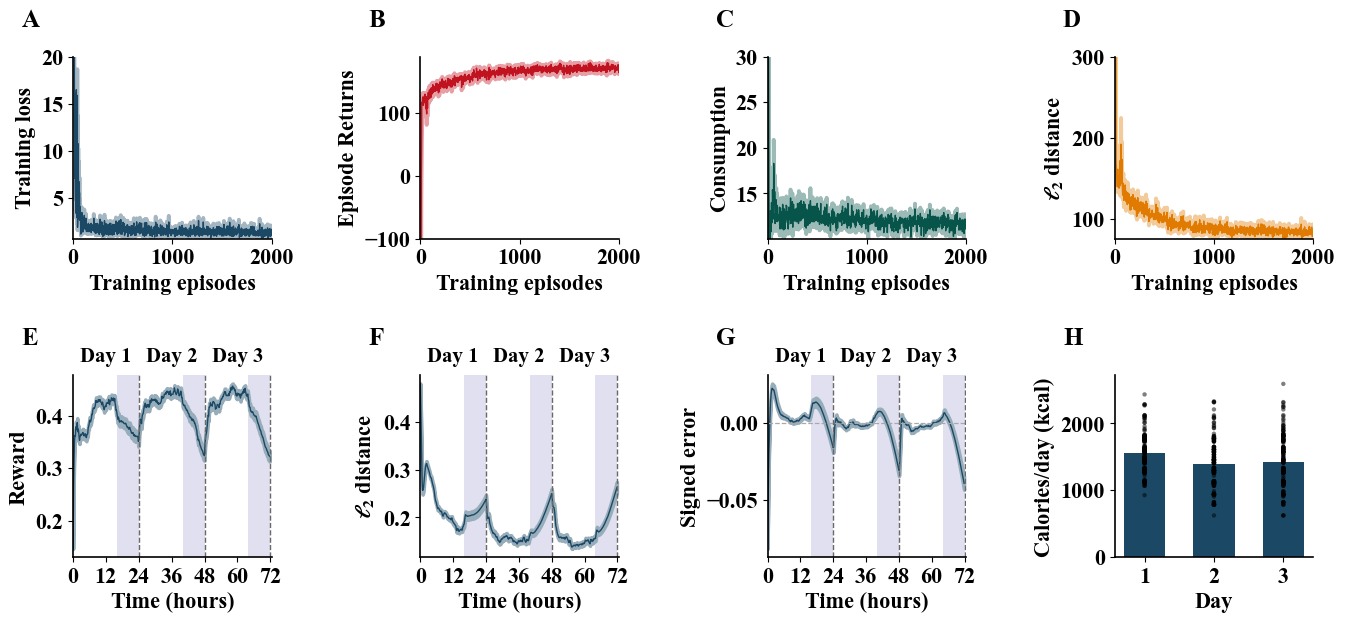

In [6]:
# ══════════════════════════════════════════════════════════════════════
#  MERGED FIGURE — training (top row) + normal-model inference (bottom row)
#  2 x 4 grid, self-contained: every input is re-read from disk here.
#    row 1 (A-D): loss / returns / consumption / distance
#                 <- results/training_data/*_training.csv
#    row 2 (E-H): reward / distance / signed error / calories per day
#                 <- results/plots_inference_normal/
#  Styling follows Fig 1 + Fig 2.1. rcParams are applied through a local
#  rc_context and every helper lives inside the function, so no other cell
#  in the notebook is affected by running this one.
# ══════════════════════════════════════════════════════════════════════
MERGED_RC = {
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    20,
    "axes.labelsize":    16,
    "xtick.labelsize":   16,
    "ytick.labelsize":   16,
    "legend.fontsize":   16,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "mathtext.default":  "bf",
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
}


def plot_training_inference_merged(
    train_dir=Path("results") / "training_data",
    infer_dir=Path("results") / "plots_inference_normal",
    section="fig1_training",
    name="training_inference",
):
    """2 x 4 merged figure: training curves (top) + inference summary (bottom).

    Reads all of its own data. Depends only on the imports cell
    (`load_seed_csvs`, `aggregate`, `save_fig`, colour constants).
    """
    train_dir, infer_dir = Path(train_dir), Path(infer_dir)

    # ── data ────────────────────────────────────────────────────────────
    train   = load_seed_csvs(train_dir)
    perstep = pd.read_pickle(infer_dir / "inference_perstep_stats.pkl")
    cal_day = pd.read_pickle(infer_dir / "calories_per_day.pkl")
    cal_ep  = pd.read_pickle(infer_dir / "calories_per_episode.pkl")

    # ── local style / layout constants ──────────────────────────────────
    ERROR            = "sem"     # error band across seeds (top row)
    BAND_TRAIN       = 0.60      # band lightening, training row  (Fig 1)
    BAND_INFER       = 0.55      # band lightening, inference row (Fig 2.1)
    LINE_TRAIN       = 1.0
    LINE_INFER       = 1.0
    LETTER_FS        = 18
    DAY_FS           = 15
    TRAIN_XMAX       = 2000
    STEPS_PER_HOUR   = 96 / 16   # 6 env steps per hour
    N_DAYS           = 3

    def _lighten(color, amount):
        r, g, b = mcolors.to_rgb(color)
        return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

    def _letter(ax, s):
        ax.text(-0.26, 1.26, s, transform=ax.transAxes, fontsize=LETTER_FS,
                fontweight="bold", va="top", ha="left")

    def _shade_sleep(ax, is_awake, scale=STEPS_PER_HOUR):
        a = np.asarray(is_awake).astype(bool)
        in_sleep, start = False, 0
        for t, awake in enumerate(a):
            if not awake and not in_sleep:
                in_sleep, start = True, t
            elif awake and in_sleep:
                ax.axvspan(start / scale, t / scale, color=SLEEP_COLOR, lw=0, zorder=0)
                in_sleep = False
        if in_sleep:
            ax.axvspan(start / scale, len(a) / scale, color=SLEEP_COLOR, lw=0, zorder=0)

    def _day_labels(ax):
        for d in range(N_DAYS):
            ax.text((d + 0.5) * 24, 1.05, f"Day {d+1}",
                    transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=DAY_FS, fontweight="bold")
        for d in range(1, N_DAYS + 1):
            ax.axvline(d * 24, color="dimgray", ls="--", lw=1.0)

    def _train_ylim(metric, mu, se):
        """Same hard limits as the standalone Fig 1 cell."""
        lo1, hi99 = np.nanpercentile(mu - se, 1), np.nanpercentile(mu + se, 99)
        return {
            "train/total_loss":  (lo1 * 0.9, 20),
            "train/reward":      (-100, hi99 * 1.05),
            "train/consumption": (lo1, 30),
            "train/distance":    (lo1, 300),
        }[metric]

    # (metric, y-label, colour, panel letter) — colours as in Fig 1
    TRAIN_PANELS = [
        ("train/total_loss",  "Training loss", "#1b4965", "A"),
        ("train/reward",      "Episode Returns",       "#c1121f", "B"),
        ("train/consumption", "Consumption",   "#07544b", "C"),
        ("train/distance",    "$\ell_2$ distance",      "#e07a00", "D"),
    ]
    # (mean col, sem col, y-label, panel letter) — Fig 2 is the normal model -> C_NORMAL
    INFER_PANELS = [
        ("reward_mean",       "reward_sem",       "Reward",       "E"),
        ("distance_mean",     "distance_sem",     "$\ell_2$ distance",     "F"),
        ("signed_error_mean", "signed_error_sem", "Signed error", "G"),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
    fig.subplots_adjust(wspace=0.75, hspace=0.75)

    # ── ROW 1 — training curves (mean ± SEM across seeds) ───────────────
    for ax, (metric, ylabel, color, letter) in zip(axes[0], TRAIN_PANELS):
        x, mu, se = aggregate(train, metric, err=ERROR)
        ax.fill_between(x, mu - se, mu + se, color=_lighten(color, BAND_TRAIN), lw=2.75)
        ax.plot(x, mu, color=color, lw=LINE_TRAIN)
        ax.set_xlabel("Training episodes")
        ax.set_ylabel(ylabel)
        ax.set_xlim(0, TRAIN_XMAX)
        ax.set_ylim(*_train_ylim(metric, mu, se))
        ax.spines[["top", "right"]].set_visible(False)
        _letter(ax, letter)

    # ── ROW 2 — inference, per-step mean ± SEM over the 200 episodes ────
    hours      = perstep["step"].values / STEPS_PER_HOUR
    is_awake   = perstep["is_awake"].values
    TOTAL_H    = len(perstep) / STEPS_PER_HOUR
    HOUR_TICKS = np.arange(0, TOTAL_H + 1, 12)

    for ax, (mcol, scol, ylabel, letter) in zip(axes[1], INFER_PANELS):
        mu, se = perstep[mcol].values, perstep[scol].values
        _shade_sleep(ax, is_awake)
        ax.fill_between(hours, mu - se, mu + se,
                        color=_lighten(C_NORMAL, BAND_INFER), lw=2.5, zorder=1)
        ax.plot(hours, mu, color=C_NORMAL, lw=LINE_INFER, zorder=2)
        if mcol.startswith("signed"):
            ax.axhline(0, color="darkgrey", lw=0.9, ls="--")
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel(ylabel)
        ax.set_xlim(0, TOTAL_H + 0.5)
        ax.set_xticks(HOUR_TICKS)
        ax.spines[["top", "right"]].set_visible(False)
        _day_labels(ax)
        _letter(ax, letter)

    # ── H. Calories per day (bars = mean over episodes, dots = episodes) ─
    ax   = axes[1, 3]
    days = cal_day["day"].values
    ax.bar(days, cal_day["mean_kcal"].values, color=C_NORMAL, width=0.6, zorder=2)
    for k, col in enumerate(cal_ep.columns):
        ax.scatter(np.full(len(cal_ep), days[k]), cal_ep[col].values,
                   s=10, color="black", alpha=0.50, edgecolors="none", zorder=3)
    ax.set_xlabel("Day")
    ax.set_ylabel("Calories/day (kcal)")
    ax.set_xticks(days)
    ax.spines[["top", "right"]].set_visible(False)
    _letter(ax, "H")

    save_fig(fig, section, name)
    return fig


with plt.rc_context(MERGED_RC):
    plot_training_inference_merged()
    plt.show()

# Figure-3 — Latent analysis

Uses the latent/decoding data saved by `infer_run.ipynb` in
`results/plots_inference_normal/` (seed 0, best checkpoint, 200 inference
episodes). Nothing here is recomputed.

- **3.1 (appendix)** 4x4 grid: the 16 bottleneck latent neurons over the
  representative episode, with food-eating instances marked (hours axis, sleep
  shaded).
- **3.2** Latent decoding of hunger / fullness — one cell for the **linear** fit
  and one for the **polynomial** fit. Each is a 2x2 grid: top = true vs held-out
  prediction time series (sleep shaded, hours), bottom = pooled predicted-vs-true
  scatter with R^2.


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_6288/905137520.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(loc="upper right", fontsize=9, frameon=False)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/baseline_latent_neurons.[png|pdf|svg|eps]


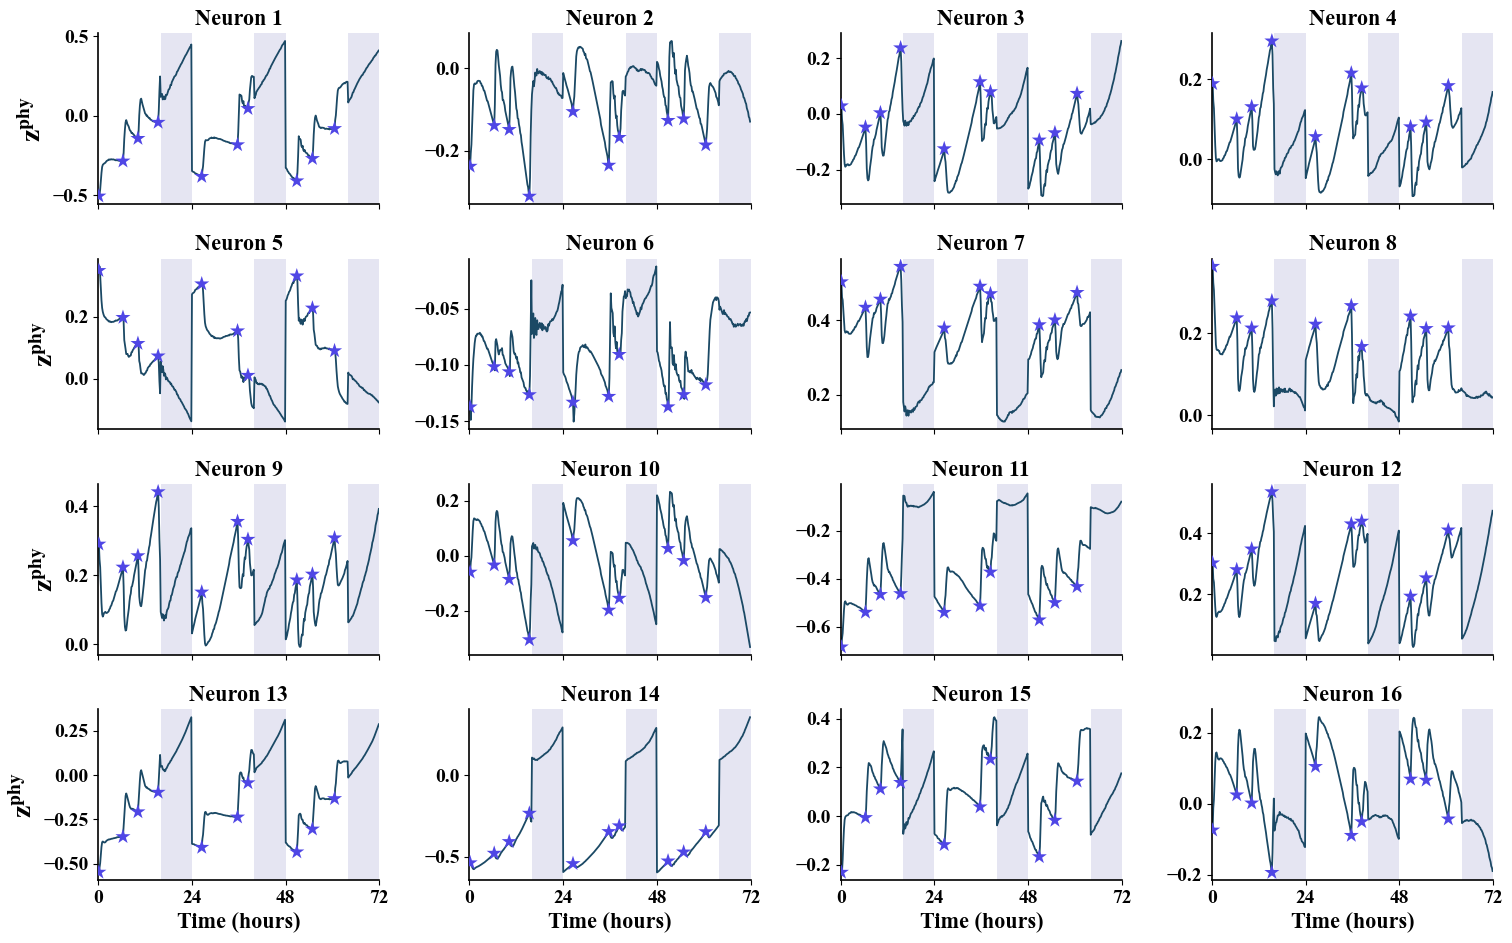

In [7]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3.1 (appendix) — 16 bottleneck latent neurons + eating instances
# ══════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

INF_DIR   = Path("results") / "plots_inference_normal"
PLOTS_DIR = Path("plots") / "plots_inference"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

STEPS_PER_HOUR = 96 / 16          # 6 steps/hour (16 h awake + 8 h asleep = 144 steps/day)

def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10, label=True):
    for k, (ws, we) in enumerate(windows):
        ax.axvspan(ws/scale, we/scale, color=color, alpha=alpha, lw=0, zorder=0,
                   )

rep       = pd.read_pickle(INF_DIR / "representative_episode.pkl")
t         = rep["t"]
hours     = t / STEPS_PER_HOUR
TOTAL_H   = len(t) / STEPS_PER_HOUR
z         = rep["z_phy"]                       # (T, 16)
ate       = rep["ate"].astype(bool)
sleep     = rep["sleep_windows"]
eat_steps = np.where(ate)[0]
eat_h     = eat_steps / STEPS_PER_HOUR

fig, axes = plt.subplots(4, 4, figsize=(18, 11), sharex=True)
fig.subplots_adjust(hspace=0.32, wspace = 0.32)
for j, ax in enumerate(axes.ravel()):
    shade_sleep_hours(ax, sleep, label=(j == 0))
    ax.plot(hours, z[:, j], color=C_NORMAL, lw=1.3, zorder=2)
    ax.scatter(eat_h, z[eat_steps, j], s=130, color=C_EAT, zorder=4, edgecolors="none", marker = '*',
               )
    # ax.axhline(0, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.set_title(f"Neuron {j+1}")
    ax.set_xlim(0, TOTAL_H)
    ax.set_xticks([0, 24, 48, 72])
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[-1, :]:
    ax.set_xlabel("Time (hours)")
for ax in axes[:, 0]:
    ax.set_ylabel("$z^{phy}$", fontsize = 20)
axes[0, 0].legend(loc="upper right", fontsize=9, frameon=False)

# fig.tight_layout()
save_fig(fig, "fig3_latent", "baseline_latent_neurons")
plt.show()


In [8]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3.2 — latent decoding of hunger / fullness (2x2)
#  top: true vs held-out prediction (time series)   bottom: pooled pred-vs-true
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

scores = pd.read_pickle(INF_DIR / "decode_scores.pkl")        # r2 per (target, fit)
dp     = pd.read_pickle(INF_DIR / "decode_predictions.pkl")   # pooled true/pred (86400)
pool   = pd.read_pickle(INF_DIR / "pooled_capture.pkl")       # pooled is_awake (86400)

# ── choices ────────────────────────────────────────────────────────────
COLOR_BY_DAY = True      # True -> colour scatter by day (awake=filled, sleep=open)
                         # False -> single colour per target
N_SAMPLES    = 4000      # how many scatter points to plot (None = all)

# ── reconstruct day (1/2/3) + awake/sleep for each pooled point ─────────
T_EP, CYCLE = 432, 144
_N         = len(dp["episode_idx"])
_step_ep   = np.tile(np.arange(T_EP), _N // T_EP)
day_pool   = _step_ep // CYCLE + 1                 # 1, 2, 3
awake_pool = pool["is_awake"].astype(bool)
DAY_COLORS = {1: "#0072B2", 2: "#E69F00", 3: "#009E73"}   # colourblind-safe

def latent_fit_figure(mode):
    TARGETS = ["hunger", "fullness"]
    TCOL    = {"hunger": "#c1121f", "fullness": "#1b4965"}

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.subplots_adjust(wspace=0.4, hspace=0.5)

    for col, tgt in enumerate(TARGETS):
        key = f"{tgt}|{mode}"
        d   = rep["decode"][key]
        r2  = float(scores[(scores.target == tgt) &
                           (scores.fit == mode)]["r2_cv"].iloc[0])

        # ──────────────────────────────────────────────────────────────
        # Top row: representative time series
        # ──────────────────────────────────────────────────────────────
        ax = axes[0, col]

        shade_sleep_hours(ax, sleep, label=(col == 0))

        ax.plot(hours, d["true"],
                color="black", lw=1.6, label="True")

        ax.plot(hours, d["pred_oof"],
                color="darkviolet", lw=1.5, ls="--",
                label="Predicted")

        ax.scatter(eat_h,
                   d["true"][eat_steps],
                   s=150,
                   color=C_EAT,
                   marker="*",
                   edgecolors="none",
                   zorder=5,
                   label="Food eaten")

        ax.set_xlim(0, TOTAL_H)
        ax.set_xticks([0, 24, 48, 72])
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel(tgt.capitalize())
        ax.spines[["top", "right"]].set_visible(False)
        for x in [24, 48, 72]:
            ax.axvline(x, color="dimgray", ls="--", lw=1.0, zorder=0)
        
        # Day labels
        for x, label in zip([12, 36, 60], ["Day 1", "Day 2", "Day 3"]):
            ax.text(
                x,
                1.02,
                label,
                transform=ax.get_xaxis_transform(),  # x in data coords, y in axes coords
                ha="center",
                va="bottom",
                fontsize=14,
                fontweight="bold",
                color="black",
            )


        ax.set_xlim(0, TOTAL_H + 0.1)

        # ──────────────────────────────────────────────────────────────
        # Bottom row: pooled prediction scatter
        # ──────────────────────────────────────────────────────────────
        ax = axes[1, col]

        yt = dp["targets"][key]["true"]
        yp = dp["targets"][key]["pred_oof"]

        ok = ~np.isnan(yp)

        lims = [
            np.nanmin([yt[ok].min(), yp[ok].min()]),
            np.nanmax([yt[ok].max(), yp[ok].max()])
        ]

        idx = np.where(ok)[0]
        if N_SAMPLES is not None and N_SAMPLES < len(idx):
            idx = np.sort(
                np.random.default_rng(0).choice(
                    idx, N_SAMPLES, replace=False
                )
            )

        if COLOR_BY_DAY:
            for day in (1, 2, 3):

                aw = idx[(day_pool[idx] == day) &
                         awake_pool[idx]]

                sl = idx[(day_pool[idx] == day) &
                         ~awake_pool[idx]]

                ax.scatter(
                    yt[aw], yp[aw],
                    s=25,
                    color=DAY_COLORS[day],
                    marker='.',
                    alpha=1.0,
                    edgecolors="none",
                    label=f"Day {day}",
                )

                ax.scatter(
                    yt[sl], yp[sl],
                    s=25,
                    facecolors=DAY_COLORS[day],
                    marker='.',
                    alpha=0.55,
                    edgecolors="none",
                )

        else:
            ax.scatter(
                yt[idx], yp[idx],
                s=5,
                alpha=0.20,
                color=TCOL[tgt],
                edgecolors="none",
            )

        ax.plot(
            lims,
            lims,
            color="black",
            ls="--",
            lw=1.2,
            label="y = x",
        )

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(f"True {tgt}")
        ax.set_ylabel(f"Predicted {tgt}")
        ax.spines[["top", "right"]].set_visible(False)

        mse = float(scores[(scores.target == tgt) &
                           (scores.fit == mode)]["mse_cv"].iloc[0])

        r = float(scores[(scores.target == tgt) &
                         (scores.fit == mode)]["r_cv"].iloc[0])

        print(f"{tgt:9s} [{mode:6s}]  held-out R2={r2:.3f}  "
              f"MSE={mse:.5f}  r={r:+.3f}")

    # ==========================================================
    # Shared legend for TOP ROW
    # ==========================================================
    top_handles = [
        Line2D([0], [0], color="black", lw=1.6, label="True"),
        Line2D([0], [0], color="darkviolet", lw=1.5,
               ls="--", label="Predicted"),
        Line2D([0], [0], marker="*", color=C_EAT,
               linestyle="None", markersize=12,
               label="Food eaten"),
        Patch(facecolor="navy", alpha=0.10, edgecolor="none",
              label="Sleep"),
    ]

    fig.legend(
        handles=top_handles,
        loc="center",
        bbox_to_anchor=(0.5, 0.475),
        ncol=4,
        frameon=False,
        fontsize=15,
    )

    # ==========================================================
    # Shared legend for BOTTOM ROW
    # ==========================================================
    if COLOR_BY_DAY:
        bottom_handles = [
            Line2D([0], [0], marker='.', color=DAY_COLORS[1],
                   linestyle='None', markersize=20, label='Day 1'),
            Line2D([0], [0], marker='.', color=DAY_COLORS[2],
                   linestyle='None', markersize=20, label='Day 2'),
            Line2D([0], [0], marker='.', color=DAY_COLORS[3],
                   linestyle='None', markersize=20, label='Day 3'),
            Line2D([0], [0], color='black',
                   ls='--', lw=1.2, label='y = x'),
        ]
    else:
        bottom_handles = [
            Line2D([0], [0], color='black',
                   ls='--', lw=1.2, label='y = x')
        ]

    fig.legend(
        handles=bottom_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.055),
        ncol=len(bottom_handles),
        frameon=False,
        fontsize=15,
    )

    # Panel labels
    for ax, lab in zip(axes.ravel(), ["A", "B", "C", "D"]):
        ax.text(
            -0.12, 1.12, lab,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            ha="left",
        )

    # Leave room for shared legends
    # fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    save_fig(fig, "fig3_latent", f"fig3_2_latent_fit_{mode}")

    return fig

hunger    [linear]  held-out R2=0.429  MSE=0.01323  r=+0.655
fullness  [linear]  held-out R2=0.569  MSE=0.00986  r=+0.754


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/fig3_2_latent_fit_linear.[png|pdf|svg|eps]


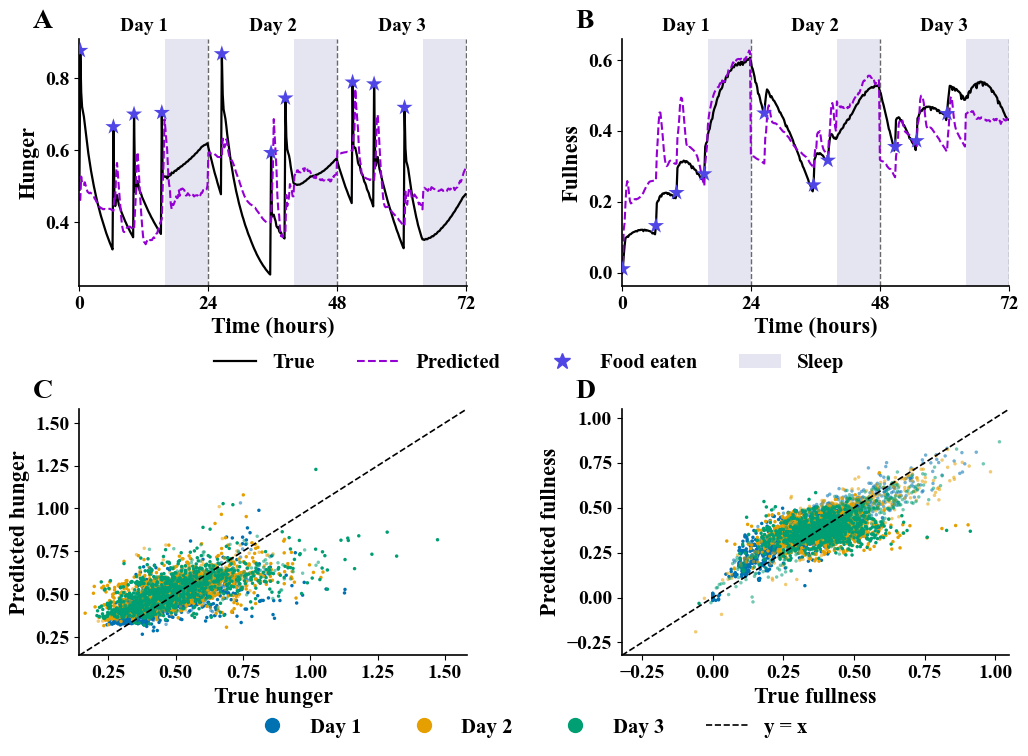

In [9]:
latent_fit_figure("linear")
plt.show()


hunger    [poly  ]  held-out R2=0.578  MSE=0.00976  r=+0.761
fullness  [poly  ]  held-out R2=0.659  MSE=0.00781  r=+0.812


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/fig3_2_latent_fit_poly.[png|pdf|svg|eps]


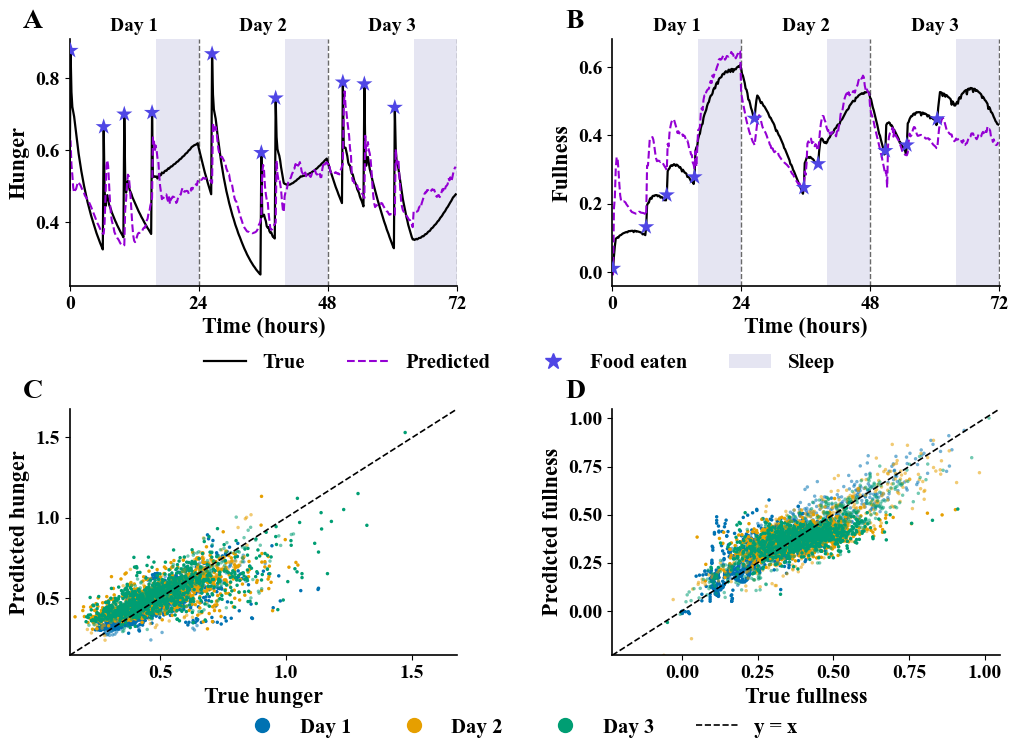

In [10]:
# ── FIGURE 3.2 — polynomial fit (same layout, reuses latent_fit_figure) ──
latent_fit_figure("poly")
plt.show()


hunger    [linear]  held-out R2=0.429  MSE=0.01323  r=+0.655
fullness  [linear]  held-out R2=0.569  MSE=0.00986  r=+0.754


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig3_latent/physiological_bottleneck_decoding.[png|pdf|svg|eps]


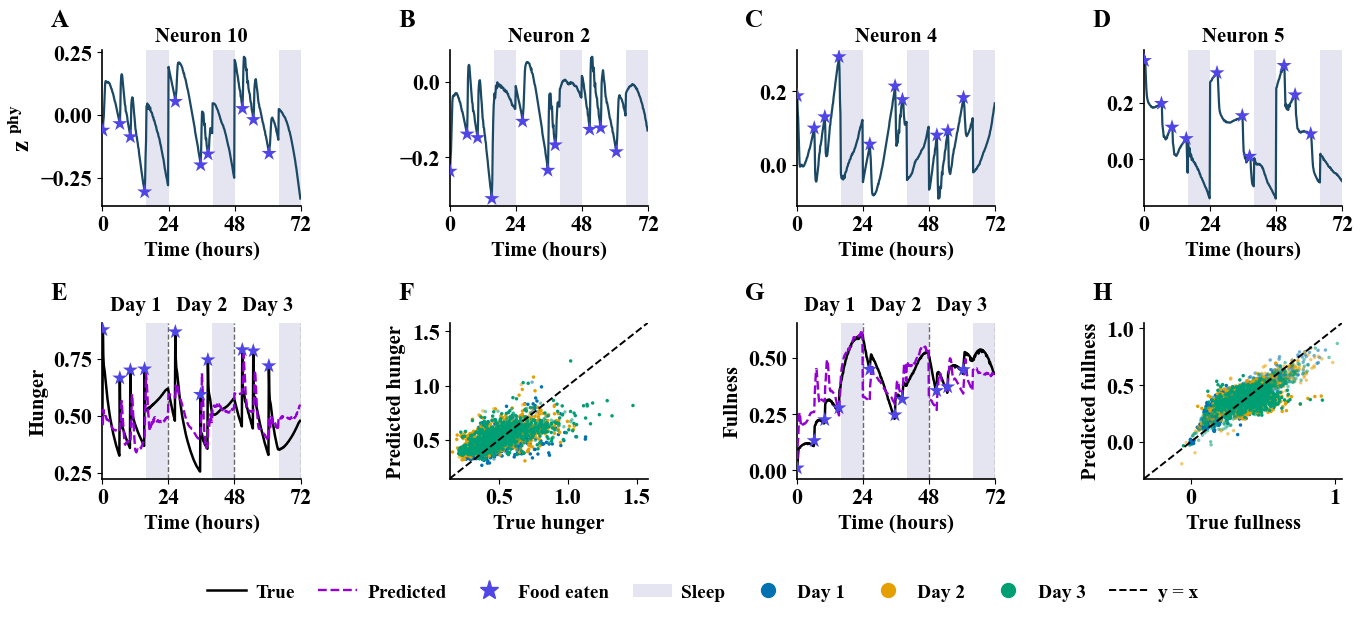

In [11]:
# ══════════════════════════════════════════════════════════════════════
#  MERGED FIGURE — latent neurons (top row) + latent decoding (bottom row)
#  2 x 4 grid, self-contained: every input is re-read from disk here.
#    row 1 (A-D): 4 selected bottleneck neurons over the representative
#                 episode, with eating instances starred
#                 <- results/plots_inference_normal/representative_episode.pkl
#    row 2 (E-H): hunger   time series / hunger   pred-vs-true,
#                 fullness time series / fullness pred-vs-true  (poly fit)
#                 <- representative_episode / decode_scores /
#                    decode_predictions / pooled_capture .pkl
#  Styling follows Fig 3.1 + Fig 3.2. rcParams are applied through a local
#  rc_context and every helper lives inside the function, so no other cell
#  in the notebook is affected by running this one.
# ══════════════════════════════════════════════════════════════════════
MERGED3_RC = {
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    15,
    "axes.labelsize":    15,
    "xtick.labelsize":   16,
    "ytick.labelsize":   16,
    "legend.fontsize":   16,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "mathtext.default":  "bf",
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
}


def plot_latent_merged(
    infer_dir=Path("results") / "plots_inference_normal",
    neurons=(10, 2, 4, 5),          # Fig 3.1 panel labels (1-based)
    mode="linear",                    # 'poly' or 'linear'
    section="fig3_latent",
    name="physiological_bottleneck_decoding",
):
    """2 x 4 merged figure: latent neurons (top) + latent decoding (bottom).

    Reads all of its own data. Depends only on the imports cell
    (`save_fig`, `C_NORMAL`, `C_EAT`).
    """
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    infer_dir = Path(infer_dir)

    # ── data ────────────────────────────────────────────────────────────
    rep    = pd.read_pickle(infer_dir / "representative_episode.pkl")
    scores = pd.read_pickle(infer_dir / "decode_scores.pkl")        # r2 per (target, fit)
    dp     = pd.read_pickle(infer_dir / "decode_predictions.pkl")   # pooled true/pred
    pool   = pd.read_pickle(infer_dir / "pooled_capture.pkl")       # pooled is_awake

    t         = rep["t"]
    z         = rep["z_phy"]                       # (T, 16)
    sleep     = rep["sleep_windows"]
    eat_steps = np.where(rep["ate"].astype(bool))[0]

    # ── local style / layout constants ──────────────────────────────────
    STEPS_PER_HOUR = 96 / 16        # 6 env steps per hour
    hours          = t / STEPS_PER_HOUR
    TOTAL_H        = len(t) / STEPS_PER_HOUR
    eat_h          = eat_steps / STEPS_PER_HOUR
    HOUR_TICKS     = [0, 24, 48, 72]
    N_DAYS         = 3

    SLEEP_KW   = dict(color="navy", alpha=0.10)    # Fig 3.1 / 3.2 convention
    LETTER_FS  = 18
    DAY_FS     = 15        # 15pt collides at this panel width (~2 in / 3 days)
    LEGEND_FS  = 14
    STAR_S     = 130                               # eating marker, row 1
    STAR_S_TS  = 130                               # eating marker, row 2 time series
    N_SAMPLES  = 4000                              # scatter points drawn (None = all)
    DAY_COLORS = {1: "#0072B2", 2: "#E69F00", 3: "#009E73"}   # colourblind-safe
    C_TRUE, C_PRED = "black", "darkviolet"

    def _letter(ax, s):
        ax.text(-0.26, 1.26, s, transform=ax.transAxes, fontsize=LETTER_FS,
                fontweight="bold", va="top", ha="left")

    def _shade_sleep(ax):
        for ws, we in sleep:
            ax.axvspan(ws / STEPS_PER_HOUR, we / STEPS_PER_HOUR,
                       lw=0, zorder=0, **SLEEP_KW)

    def _day_labels(ax):
        for d in range(N_DAYS):
            ax.text((d + 0.5) * 24, 1.05, f"Day {d+1}",
                    transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=DAY_FS, fontweight="bold")
        for d in range(1, N_DAYS + 1):
            ax.axvline(d * 24, color="dimgray", ls="--", lw=1.0, zorder=0)

    def _score(tgt, col):
        return float(scores[(scores.target == tgt) & (scores.fit == mode)][col].iloc[0])

    # ── pooled scatter bookkeeping: day (1/2/3) + awake per pooled point ─
    # C_EAT    = "#5c3a21" 
    # C_EAT    = "#4F46E5" 
    T_EP, CYCLE = len(t), 144
    _n_ep       = len(dp["episode_idx"]) // T_EP
    day_pool    = (np.tile(np.arange(T_EP), _n_ep) // CYCLE) + 1
    awake_pool  = np.asarray(pool["is_awake"]).astype(bool)

    fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
    fig.subplots_adjust(wspace=0.75, hspace=0.75, bottom=0.22)

    # ── ROW 1 — selected bottleneck neurons ─────────────────────────────
    for ax, n_lab, letter in zip(axes[0], neurons, ["A", "B", "C", "D"]):
        j = int(n_lab) - 1                          # panel label -> column index
        _shade_sleep(ax)
        ax.plot(hours, z[:, j], color=C_NORMAL, lw=1.6, zorder=2)
        ax.scatter(eat_h, z[eat_steps, j], s=STAR_S, color=C_EAT, marker="*",
                   edgecolors="none", zorder=4)
        ax.set_title(f"Neuron {n_lab}")
        ax.set_xlabel("Time (hours)")
        ax.set_xlim(0, TOTAL_H)
        ax.set_xticks(HOUR_TICKS)
        ax.spines[["top", "right"]].set_visible(False)
        _letter(ax, letter)
    axes[0, 0].set_ylabel("$z~^{phy}$", fontsize = 18)

    # ── ROW 2 — decoding: (time series, pred-vs-true) per target ────────
    for c0, tgt in enumerate(["hunger", "fullness"]):
        key = f"{tgt}|{mode}"
        d   = rep["decode"][key]
        r2  = _score(tgt, "r2_cv")

        # ---- time series (held-out prediction over the representative ep)
        ax = axes[1, 2 * c0]
        _shade_sleep(ax)
        ax.plot(hours, d["true"],     color=C_TRUE, lw=1.8, zorder=2)
        ax.plot(hours, d["pred_oof"], color=C_PRED, lw=1.7, ls="--", zorder=3)
        ax.scatter(eat_h, np.asarray(d["true"])[eat_steps], s=STAR_S_TS,
                   color=C_EAT, marker="*", edgecolors="none", zorder=5)
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel(tgt.capitalize())
        ax.set_xlim(0, TOTAL_H + 0.1)
        ax.set_xticks(HOUR_TICKS)
        ax.spines[["top", "right"]].set_visible(False)
        _day_labels(ax)
        _letter(ax, ["E", "G"][c0])

        # ---- pooled predicted vs true --------------------------------
        ax = axes[1, 2 * c0 + 1]
        yt = np.asarray(dp["targets"][key]["true"])
        yp = np.asarray(dp["targets"][key]["pred_oof"])
        ok = ~np.isnan(yp)
        lims = [np.nanmin([yt[ok].min(), yp[ok].min()]),
                np.nanmax([yt[ok].max(), yp[ok].max()])]

        idx = np.where(ok)[0]
        if N_SAMPLES is not None and N_SAMPLES < len(idx):
            idx = np.sort(np.random.default_rng(0).choice(idx, N_SAMPLES, replace=False))

        for day in (1, 2, 3):
            aw = idx[(day_pool[idx] == day) & awake_pool[idx]]
            sl = idx[(day_pool[idx] == day) & ~awake_pool[idx]]
            ax.scatter(yt[aw], yp[aw], s=25, color=DAY_COLORS[day], marker=".",
                       alpha=1.00, edgecolors="none")
            ax.scatter(yt[sl], yp[sl], s=25, color=DAY_COLORS[day], marker=".",
                       alpha=0.55, edgecolors="none")
        ax.plot(lims, lims, color="black", ls="--", lw=1.4, zorder=4)

        # ax.text(0.04, 0.96, f"$R^2$ = {r2:.2f}", transform=ax.transAxes,
        #         va="top", ha="left", fontsize=14)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel(f"True {tgt}")
        ax.set_ylabel(f"Predicted {tgt}")
        ax.spines[["top", "right"]].set_visible(False)
        _letter(ax, ["F", "H"][c0])

        print(f"{tgt:9s} [{mode:6s}]  held-out R2={r2:.3f}  "
              f"MSE={_score(tgt, 'mse_cv'):.5f}  r={_score(tgt, 'r_cv'):+.3f}")

    # ── shared legend (bottom) ──────────────────────────────────────────
    handles = [
        Line2D([0], [0], color=C_TRUE, lw=1.8, label="True"),
        Line2D([0], [0], color=C_PRED, lw=1.7, ls="--", label="Predicted"),
        Line2D([0], [0], marker="*", color=C_EAT, linestyle="None",
               markersize=14, label="Food eaten"),
        Patch(facecolor="navy", alpha=0.10, edgecolor="none", label="Sleep"),
        Line2D([0], [0], marker=".", color=DAY_COLORS[1], linestyle="None",
               markersize=20, label="Day 1"),
        Line2D([0], [0], marker=".", color=DAY_COLORS[2], linestyle="None",
               markersize=20, label="Day 2"),
        Line2D([0], [0], marker=".", color=DAY_COLORS[3], linestyle="None",
               markersize=20, label="Day 3"),
        Line2D([0], [0], color="black", ls="--", lw=1.4, label="y = x"),
    ]
    fig.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 0.045),
               ncol=len(handles), frameon=False, fontsize=LEGEND_FS,
               columnspacing=1.2, handletextpad=0.5)

    save_fig(fig, section, name)
    return fig


with plt.rc_context(MERGED3_RC):
    plot_latent_merged()
    plt.show()

Fullness : annotated -> Neuron 11 (+1.613), Neuron 3 (+1.508)   |   top |w| -> N7(-2.54), N11(+1.61), N3(+1.51), N14(-1.46), N8(+1.32)
Hunger   : annotated -> Neuron 5 (+2.746), Neuron 6 (+1.725)   |   top |w| -> N5(+2.75), N6(+1.73), N12(-1.45), N2(-1.14), N13(+0.98)
saved fig3_latent/decoder_weights.[png|pdf|svg|eps]


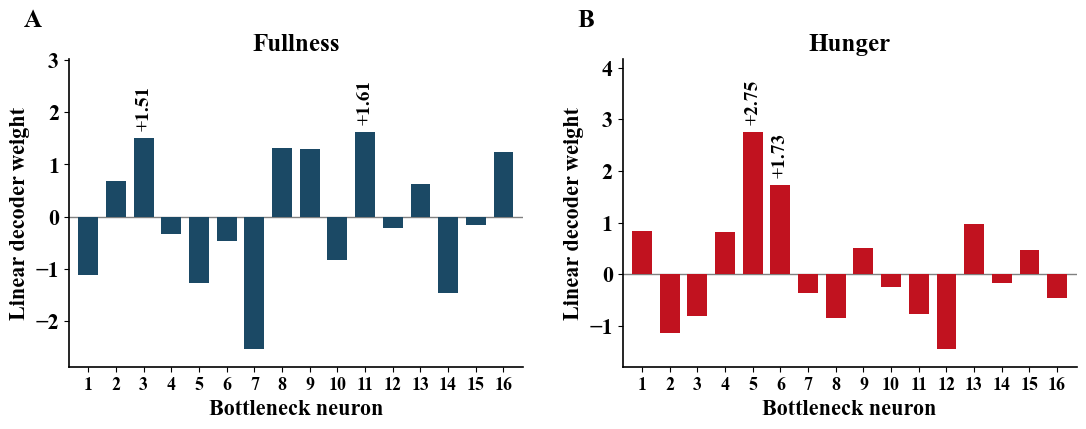

In [12]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3 (supp) — linear-decoder weights per bottleneck neuron
#  1 x 2 grid, self-contained: the weights are re-read from disk here.
#    A (left)  : fullness decoder weights   (blue)
#    B (right) : hunger   decoder weights   (red)
#  Bars are the linear decoder coefficients saved by `infer_run.ipynb`
#  (results/plots_inference_normal/decoder_weights.pkl). The two largest
#  POSITIVE weights in each panel have their value written above the bar.
#  Neurons are labelled 1-based to match Fig 3.1 / the merged Fig 3 cell,
#  i.e. "Neuron 5" is z_phy column 4.
#  rcParams are applied through a local rc_context and every helper lives
#  inside the function, so no other cell in the notebook is affected.
# ══════════════════════════════════════════════════════════════════════
DECW_RC = {
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    18,
    "axes.labelsize":    16,
    "xtick.labelsize":   13,
    "ytick.labelsize":   16,
    "legend.fontsize":   14,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "mathtext.default":  "bf",
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
}


def plot_decoder_weights(
    infer_dir=Path("results") / "plots_inference_normal",
    section="fig3_latent",
    name="decoder_weights",
):
    """1 x 2 bar figure: linear decoder weight of every bottleneck neuron.

    Left = fullness, right = hunger. The N_MARK highest positive weights per
    panel have their value written above the bar. Reads all of its own data;
    depends only on the imports cell (`save_fig`, `C_NORMAL`, `C_OVER`).
    """
    infer_dir = Path(infer_dir)

    # ── data ────────────────────────────────────────────────────────────
    w = pd.read_pickle(infer_dir / "decoder_weights.pkl")   # neuron, w_hunger, w_fullness

    # ── local style / layout constants ──────────────────────────────────
    LETTER_FS  = 18
    N_MARK     = 2          # how many top positive bars to annotate
    ANN_FS     = 14         # weight written above the bar
    ANN_COLOR  = "black"
    BAR_W      = 0.72
    HEADROOM   = 0.34       # extra y-range above the tallest bar, as a fraction

    # (weight column, nice name, colour, panel letter)
    PANELS = [
        ("w_fullness", "Fullness", C_NORMAL, "A"),
        ("w_hunger",   "Hunger",   C_OVER,   "B"),
    ]

    def _letter(ax, s):
        ax.text(-0.10, 1.16, s, transform=ax.transAxes, fontsize=LETTER_FS,
                fontweight="bold", va="top", ha="left")

    neuron_lab = np.asarray(w["neuron"].values, dtype=int) + 1   # 0-based -> Neuron N
    x          = np.arange(len(neuron_lab))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
    fig.subplots_adjust(wspace=0.22)

    for ax, (col, nice, color, letter) in zip(axes, PANELS):
        v = np.asarray(w[col].values, dtype=float)
        ax.bar(x, v, BAR_W, color=color, zorder=2)
        ax.axhline(0, color="grey", lw=1.0, zorder=1)

        # ── value above the N_MARK largest POSITIVE weights ─────────────
        span = v.max() - min(v.min(), 0.0)
        top  = np.argsort(v)[::-1][:N_MARK]      # most positive first
        for j in top:
            # rotated so the value stays centred on its own bar: a horizontal
            # label is wider than the bar pitch and would run over its neighbour
            ax.text(x[j], v[j] + 0.035 * span, f"{v[j]:+.2f}",
                    ha="center", va="bottom", rotation=90,
                    fontsize=ANN_FS, fontweight="bold", color=ANN_COLOR, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(neuron_lab)
        ax.set_xlim(-0.7, len(x) - 0.3)
        ax.set_ylim(min(v.min(), 0.0) - 0.08 * span, v.max() + HEADROOM * span)
        ax.set_xlabel("Bottleneck neuron")
        ax.set_ylabel("Linear decoder weight")
        ax.set_title(nice)
        ax.spines[["top", "right"]].set_visible(False)
        _letter(ax, letter)

        order = np.argsort(np.abs(v))[::-1][:5]
        print(f"{nice:9s}: annotated -> "
              + ", ".join(f"Neuron {neuron_lab[j]} ({v[j]:+.3f})" for j in top)
              + "   |   top |w| -> "
              + ", ".join(f"N{neuron_lab[k]}({v[k]:+.2f})" for k in order))

    save_fig(fig, section, name)
    return fig


with plt.rc_context(DECW_RC):
    plot_decoder_weights()
    plt.show()

# Figure 4 — Latent view ablation (3D nutrient-space trajectories)

Uses `results/plots_latent_ablation/conditions_capture.pkl` (pooled over SEEDS x N_INFERENCE; representative
best-return rollout per condition). Each nutrient is a normalised axis; trajectories are coloured
light -> dark over time, **solid = awake / dashed = sleep**, food-eaten steps are
starred, and the target region is shown as a translucent box + hollow sphere.

Conditions are discovered from the data by bias sign: most-negative bias = under-eating,
`baseline` (bias 0), most-positive bias = over-eating.

Two cells: (a) all conditions in one 3D axes, (b) one 3D panel per condition.

> **Note on interpretation:** this shows a single *randomly chosen* rollout per condition (not the best-return one). It is one example draw, so it need not equal the pooled averages; the calorie bars in the Fig-4 summary cell are means over all pooled sims. Re-running the capture (or setting `REP_PICK_SEED=None`) draws a different random example.

In [13]:
# ══════════════════════════════════════════════════════════════════════
#  3D nutrient-space trajectories — setup + COMBINED plot (all conditions)
#  Conditions are discovered from the pickle by BIAS SIGN, so this is robust
#  to the bias magnitudes changing between runs (e.g. -1.05/+1.75 vs ±1.15).
# ══════════════════════════════════════════════════════════════════════
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

LAT_DIR   = Path("results") / "plots_latent_ablation"
PLOTS_DIR = Path("plots") / "plots_latent_ablation"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

cc    = pd.read_pickle(LAT_DIR / "conditions_capture.pkl")
meta  = cc["meta"]; runs = cc["runs"]
names = meta["nutrient_names"]                          # e.g. ['glucose','peptides','fatty_acids']
low, high, ctr = meta["target_low"], meta["target_high"], meta["target_norm"]
sleep_wins = meta["sleep_windows"]
AX_LABELS = ["$ \overline{s}_{G}$", "$\overline{s}_{SP}$", "$\overline{s}_{FF}$"]

# ── discover conditions by bias sign (baseline / under-eating / over-eating) ──
_bias  = {lab: float(r["bias"]) for lab, r in runs.items()}
_base  = next((l for l, b in _bias.items() if abs(b) < 1e-6),
              min(_bias, key=lambda l: abs(_bias[l])))
_under = min(_bias, key=lambda l: _bias[l])            # most negative -> under-eating
_over  = max(_bias, key=lambda l: _bias[l])            # most positive -> over-eating
COND_MAP = {
    _base:  ("Baseline",     plt.cm.Blues),
    _under: ("Under-eating (b = -1.0)", plt.cm.Oranges),
    _over:  ("Over-eating (b = +1.0)",  plt.cm.Reds),
}
ORDER = [_base, _under, _over]
T_EP  = int(np.asarray(runs[_base]["phy_representative"]).shape[0])
print("Conditions:", {l: COND_MAP[l][0] for l in ORDER},
      "| bias:", {l: round(_bias[l], 3) for l in ORDER}, "| T =", T_EP)

def _awake_mask(T, wins):
    a = np.ones(T, bool)
    for s, e in wins:
        a[s:e] = False
    return a
AWAKE = _awake_mask(T_EP, sleep_wins)

def draw_target(ax):
    """Nested translucent ellipsoids (light->dark toward centre) at the target."""
    c = (low + high) / 2.0
    a0 = (high - low) / 2.0 * 2.5 * np.array([0.2, 2.4, 1.0]) #1.75        # outer semi-axes
    u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:16j]

    shells = [(1.00, "#32A432", 0.10),      # (scale, colour, alpha)  outer, light
              (0.66, "#3FA23F", 0.13),      # middle
              (0.34, "#083C08", 0.16)]      # inner, dark
    for sc, col, al in shells:
        a = a0 * sc
        xs = c[0] + a[0]*np.cos(u)*np.sin(v)
        ys = c[1] + a[1]*np.sin(u)*np.sin(v)
        zs = c[2] + a[2]*np.cos(v)
        ax.plot_surface(xs, ys, zs, color=col, alpha=al, linewidth=0, shade=False, zorder=0)
    ax.scatter([ctr[0]], [ctr[1]], [ctr[2]], color="#1B6B1B", s=30, marker="o", zorder=1)

def plot_traj(ax, phy, color, eat_steps, lw=1.0):
    """Solid uniform-colour 3D line (solid=awake, dashed=sleep) + food-eaten stars."""
    base = mcolors.to_rgb(color)
    pts  = phy.reshape(-1, 1, 3)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    styles = ["solid" if AWAKE[i] else "dashed" for i in range(len(segs))]
    lc = Line3DCollection(segs, colors=base, linestyles=styles, linewidths=lw, zorder=5, alpha = 0.75)
    ax.add_collection3d(lc)
    ax.scatter(phy[eat_steps, 0], phy[eat_steps, 1], phy[eat_steps, 2],
               marker="*", s=40, color=C_EAT, depthshade=False, zorder=6)
    ax.grid(False)

def set3d(ax):
    ax.set_xlabel(AX_LABELS[0]); ax.set_ylabel(AX_LABELS[1]); ax.set_zlabel(AX_LABELS[2])
    ax.set_xlim(-0.15, 1.0); ax.set_ylim(-0.3, 0.9); ax.set_zlim(-0.05, 0.8)
    ax.view_init(elev=22, azim=-60); ax.grid(False)


Conditions: {'baseline': 'Baseline', 'bias=-1': 'Under-eating (b = -1.0)', 'bias=+1.5': 'Over-eating (b = +1.0)'} | bias: {'baseline': 0.0, 'bias=-1': -1.0, 'bias=+1.5': 1.5} | T = 432


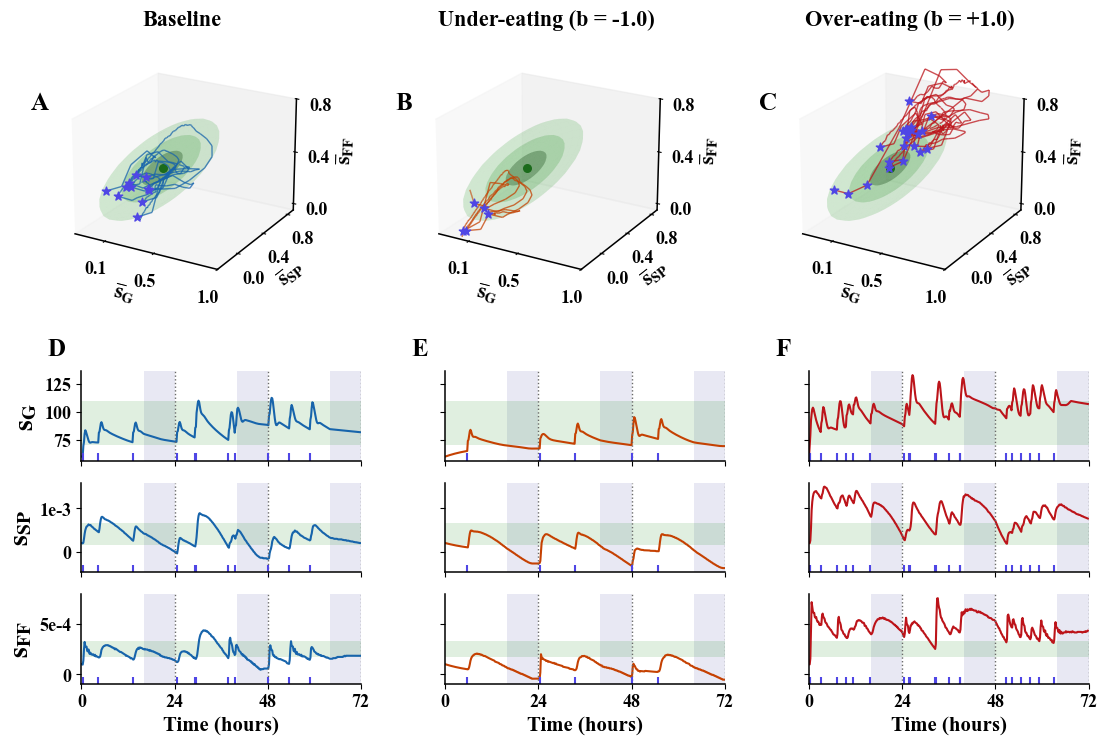

In [14]:
# ══════════════════════════════════════════════════════════════════════
#  Journal figure — columns = condition
#  row 1 (tall): 3D nutrient-space trajectory (A/B/C)
#  rows 2-4: raw nutrient dynamics stacked (glucose / fatty acids / peptides),
#            shared y per nutrient across conditions; eaten events merged as
#            thick short ticks at each panel base; fatty-acids/peptides ticks
#            in 1e-4 format; label D/E/F
#  (reuses helpers/data from the combined 3D cell above)
# ══════════════════════════════════════════════════════════════════════
from matplotlib.transforms import blended_transform_factory
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({"font.family":"serif","font.serif":["Times New Roman","DejaVu Serif"],
    "font.weight":"bold","axes.labelweight":"bold","axes.titleweight":"bold",
    "font.size":14,"axes.titlesize":16,"axes.labelsize":15,"xtick.labelsize":13,"ytick.labelsize":13,"axes.linewidth":1.1})

minmax=meta["nutrient_minmax"]; low_n=meta["target_low"]; high_n=meta["target_high"]
STEPS_PER_HOUR=6; TOTAL_H=432/STEPS_PER_HOUR; hours=np.arange(432)/STEPS_PER_HOUR
NUT_ROWS=["glucose","peptides","fatty_acids"]
NUT_NICE={"glucose":"$s_G$","fatty_acids":"$s_{FF}$","peptides":"$s_{SP}$"}
SCI_ROWS={"fatty_acids","peptides"}
L3D=["A","B","C"]; LBOT=["D","E","F"]

def sci_fmt(v,_):
    if v==0: return "0"
    exp=int(np.floor(np.log10(abs(v)))); m=v/10**exp
    return f"{m:g}e{exp}"
def raw(nm,v):
    vmin,vmax=minmax[nm]; return v*(vmax-vmin)+vmin
def shade_h(ax):
    for s,e in sleep_wins: ax.axvspan(s/STEPS_PER_HOUR,e/STEPS_PER_HOUR,color="navy",alpha=0.09,lw=0)
def day_lines(ax):
    for x in (24,48,72): ax.axvline(x,color="dimgray",lw=1.0,ls=":")

fig=plt.figure(figsize=(13,9))
gs=fig.add_gridspec(4,3,height_ratios=[4,1,1,1],hspace=0.14,wspace=0.30)
row_ref={}; colx={}
for k,lab in enumerate(ORDER):
    nice,cmap=COND_MAP[lab]; col=cmap(0.8)
    phy=runs[lab]["phy_representative"]; eat_h=runs[lab]["eat_steps"]/STEPS_PER_HOUR
    ax=fig.add_subplot(gs[0,k],projection="3d",computed_zorder=False)
    draw_target(ax); plot_traj(ax,phy,col,runs[lab]["eat_steps"]); set3d(ax)
    ax.set_xticks([0.1,0.5,1.0]); 
    ax.set_yticks([0,0.4,0.8]); 
    ax.set_zticks([0,0.4,0.8])
    ax.set_box_aspect(None, zoom=0.9)          # shrink content so right z-axis label fits
    _p = ax.get_position(); ax.set_position([_p.x0 - 0.03, _p.y0, _p.width, _p.height])  # nudge 3D panel left
    ax.set_title(nice,pad=0)
    ax.text2D(-0.04,0.7,L3D[k],transform=ax.transAxes,fontsize=18,fontweight="bold",va="bottom",ha="left")
    for ri,nm in enumerate(NUT_ROWS):
        i=names.index(nm)
        ax=fig.add_subplot(gs[1+ri,k], sharey=row_ref.get(nm), sharex=colx.get(k))
        if nm not in row_ref: row_ref[nm]=ax
        if k not in colx: colx[k]=ax
        shade_h(ax)
        ax.axhspan(raw(nm,low_n[i]),raw(nm,high_n[i]),color="green",alpha=0.12,lw=0)
        ax.plot(hours,raw(nm,phy[:,i]),color=col,lw=1.5)
        day_lines(ax)
        tr=blended_transform_factory(ax.transData,ax.transAxes)
        ax.vlines(eat_h,0.0,0.08,transform=tr,color=C_EAT,lw=1.5)
        ax.set_xlim(0,TOTAL_H+0.1); ax.set_xticks([0,24,48,72])
        ax.spines[["top","right"]].set_visible(False)
        if ri<2: plt.setp(ax.get_xticklabels(),visible=False)
        else: ax.set_xlabel("Time (hours)")
        if k==0:
            ax.set_ylabel(NUT_NICE[nm], fontsize = 20)
            if nm in SCI_ROWS: ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
        else:
            plt.setp(ax.get_yticklabels(),visible=False)
        if ri==0:
            ax.text(-0.12,1.12,LBOT[k],transform=ax.transAxes,fontsize=18,fontweight="bold",va="bottom",ha="left")

# save_fig(fig, "fig4_ablation", "bias_expt_nutrient_trajectories")
plt.show()


In [15]:

# ORDER = [_base, _under, _over]

runs["baseline"]["eat_steps"]/STEPS_PER_HOUR

array([ 0.33333333,  4.33333333, 13.16666667, 24.5       , 29.16666667,
       29.5       , 37.83333333, 39.5       , 48.16666667, 53.5       ,
       58.83333333])

In [16]:
runs.keys()

dict_keys(['bias=-1', 'baseline', 'bias=+1.5'])

In [17]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 4-style summary — per bias case (no / low / high bias)
#  Reward · Distance · Signed error (per-step mean±SE) + Calories per day
#  A/B/C -> results/plots_latent_ablation/perstep_by_condition.pkl (pooled mean/sem)
#  D     -> conditions_capture 'cal_per_day' (pooled SEEDS x N_INFERENCE),
#           bars = mean±SEM over sims + per-sim scatter  (same as TD Fig 5.2-D)
#  Conditions discovered from the data; robust to bias-magnitude changes.
# ══════════════════════════════════════════════════════════════════════
import warnings
import matplotlib.colors as mcolors

LAT_DIR = Path("results") / "plots_latent_ablation"
perstep_all = pd.read_pickle(LAT_DIR / "perstep_by_condition.pkl")   # long-form mean/sem
per_ep_all  = pd.read_pickle(LAT_DIR / "per_episode_by_condition.pkl")
_cc         = pd.read_pickle(LAT_DIR / "conditions_capture.pkl")
_meta       = _cc["meta"]; _runs = _cc["runs"]

# ── discover the three conditions from the per-step table ───────────────
_cond_bias = (perstep_all[["condition", "bias"]]
              .drop_duplicates().set_index("condition")["bias"])
_base = "baseline" if "baseline" in _cond_bias.index else _cond_bias.abs().idxmin()
CASES = [                                            # (nice name, condition key)
    ("no bias",   _base),
    ("low bias",  _cond_bias.idxmin()),             # most negative bias (under-eating)
    ("high bias", _cond_bias.idxmax()),             # most positive bias (over-eating)
]

# ── config (T / days / sleep derived from the saved data) ───────────────
STEPS_PER_HOUR = 6
T_EP        = int(perstep_all["step"].max()) + 1
TOTAL_HOURS = T_EP / STEPS_PER_HOUR
hours       = np.arange(T_EP) / STEPS_PER_HOUR
HOUR_TICKS  = np.arange(0, TOTAL_HOURS + 1, 12)
SLEEP_WINS  = _meta["sleep_windows"]
N_DAYS      = int(round(TOTAL_HOURS / 24))

PANELS = [("rew", "Reward"), ("dist", "Distance"), ("signed", "Signed error")]
CASE_COLOR = {"no bias": C_NORMAL, "low bias": C_UNDER, "high bias": C_OVER}
BAND_LIGHTEN, LINE_W, PANEL_LABEL_SIZE = 0.55, 1.0, 22

def lighten(color, amount):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1-r)*amount, g + (1-g)*amount, b + (1-b)*amount)


def shade_sleep(ax):
    for ws, we in SLEEP_WINS:
        ax.axvspan(ws/STEPS_PER_HOUR, we/STEPS_PER_HOUR, color=SLEEP_COLOR, lw=0, zorder=0)

def add_day_labels(ax):
    for d in range(N_DAYS):
        ax.text((d + 0.5) * 24, 1.04, f"Day {d+1}", transform=ax.get_xaxis_transform(),
                ha="center", va="bottom", fontsize=15, fontweight="bold")
    for d in range(1, N_DAYS):
        ax.axvline(d * 24, color="dimgray", ls="--", lw=1.0)

def panel_letter(ax, letter):
    ax.text(-0.16, 1.22, letter, transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE, fontweight="bold", va="top", ha="left")

def _cal_per_day(key):
    """(n_sims, n_days) per-day kcal for a condition, pooled over SEEDS x N_INFERENCE."""
    run = _runs.get(key)
    if run is None or "cal_per_day" not in run:
        return None
    return np.asarray(run["cal_per_day"], dtype=float)



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_2_conditions_overlay.[png|pdf|svg|eps]


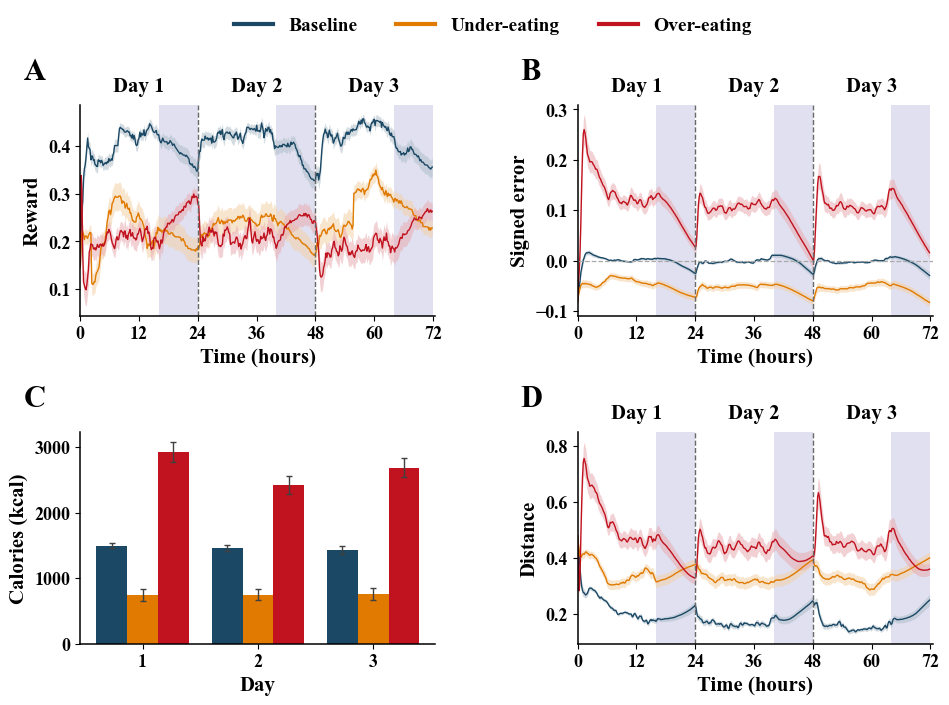

In [18]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 4 (overlay) — all conditions on shared axes (2x2)
#  Reward · Signed error · Consumption (kcal/day) · Distance
#  baseline / under-eating / over-eating overlaid in condition colours + legend
#  (reuses data + helpers defined in the per-case summary cell above)
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

DISPLAY_NICE = {"no bias": "Baseline", "low bias": "Under-eating", "high bias": "Over-eating"}

fig, ((ax_r, ax_s), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(11, 7))
fig.subplots_adjust(wspace=0.4, hspace=0.55)

TS_PANELS = [("rew", "Reward", ax_r, "A"),
             ("signed", "Signed error", ax_s, "B"),
             ("dist", "Distance", ax_d, "D")]

for _m, _yl, ax, _lt in TS_PANELS:          # sleep shading once per time-series panel
    shade_sleep(ax)

for nice, key in CASES:
    col = CASE_COLOR[nice]
    sub = perstep_all[perstep_all.condition == key]
    for metric, ylabel, ax, letter in TS_PANELS:
        m = sub[sub.metric == metric].sort_values("step")
        mu, se = m["mean"].values, m["sem"].values
        ax.fill_between(hours, mu - se, mu + se, color=lighten(col, 0.65),
                        lw=0, alpha=0.55, zorder=1)
        ax.plot(hours, mu, color=col, lw=LINE_W, zorder=2, label=DISPLAY_NICE[nice])

for metric, ylabel, ax, letter in TS_PANELS:
    if metric == "signed":
        ax.axhline(0, color="darkgrey", lw=0.9, ls="--")
    ax.set_xlabel("Time (hours)"); ax.set_ylabel(ylabel)
    ax.set_xlim(0, TOTAL_HOURS + 0.5); ax.set_xticks(HOUR_TICKS)
    add_day_labels(ax); panel_letter(ax, letter)

# ── C. Consumption: grouped calories/day bars (one group per day) ───────
n_c = len(CASES); bw = 0.8 / n_c; day_ref = None
for j, (nice, key) in enumerate(CASES):
    cm = _cal_per_day(key)
    if cm is None:
        continue
    xd = np.arange(1, cm.shape[1] + 1); day_ref = xd
    cnt = np.sum(~np.isnan(cm), axis=0)
    dmean = np.nanmean(cm, axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dstd = np.nanstd(cm, axis=0, ddof=1)
    dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
    off = (j - (n_c - 1) / 2) * bw
    ax_c.bar(xd + off, dmean, yerr=dsem, width=bw, color=CASE_COLOR[nice],
             capsize=2, error_kw=dict(lw=1.0, ecolor="0.25"),
             label=DISPLAY_NICE[nice], zorder=2)
if day_ref is not None:
    ax_c.set_xticks(day_ref)
ax_c.set_xlabel("Day"); ax_c.set_ylabel("Calories (kcal)")
panel_letter(ax_c, "C")

# ── shared condition legend ─────────────────────────────────────────────
handles = [Line2D([0], [0], color=CASE_COLOR[nice], lw=3, label=DISPLAY_NICE[nice])
           for nice, _ in CASES]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.03),
           ncol=len(CASES), frameon=False, fontsize=14)

save_fig(fig, "fig4_ablation", "fig4_2_conditions_overlay")
plt.show()


### Fig 4 (supp) — All phy-bottleneck neurons under each bias condition

Three N×N grids (baseline / under-eating / over-eating) showing every bottleneck neuron's activation over the **same seed-42 example rollout** used by the Fig-4 nutrient trajectory and the z_phy grid. Food-consumed steps are starred; sleep windows shaded. Data: `conditions_capture.pkl` → `z_representative` / `ate_representative` (nothing recomputed).

In [19]:
# # ══════════════════════════════════════════════════════════════════════
# #  Fig 4 (supp) — all phy-bottleneck neurons under each bias condition
# #  one N x N grid per condition (baseline / under-eating / over-eating),
# #  SAME seed-42 example rollout as the Fig-4 nutrient & z_phy plots.
# #  data: conditions_capture.pkl -> z_representative / ate_representative
# # ══════════════════════════════════════════════════════════════════════
# LAT_DIR = Path("results") / "plots_latent_ablation"
# cc   = pd.read_pickle(LAT_DIR / "conditions_capture.pkl")
# runs = cc["runs"]; meta = cc["meta"]; sleep = meta["sleep_windows"]

# z0 = np.asarray(next(iter(runs.values()))["z_representative"])
# T_EP, Z_DIM   = z0.shape
# STEPS_PER_HOUR = 6.0
# hours   = np.arange(T_EP) / STEPS_PER_HOUR
# TOTAL_H = T_EP / STEPS_PER_HOUR
# NCOL = 4
# NROW = int(np.ceil(Z_DIM / NCOL))

# # discover conditions by bias sign (robust to bias magnitudes changing)
# _bias  = {lab: float(r["bias"]) for lab, r in runs.items()}
# _base  = next((l for l, b in _bias.items() if abs(b) < 1e-6), min(_bias, key=lambda l: abs(_bias[l])))
# _under = min(_bias, key=lambda l: _bias[l])
# _over  = max(_bias, key=lambda l: _bias[l])
# COND_NICE  = {_base: "Baseline", _under: "Under-eating", _over: "Over-eating"}
# COND_COLOR = {_base: C_NORMAL, _under: C_UNDER, _over: C_OVER}
# ORDER      = [_base, _under, _over]

# def shade_sleep_hours(ax, windows, scale=STEPS_PER_HOUR, color="navy", alpha=0.10):
#     for ws, we in windows:
#         ax.axvspan(ws/scale, we/scale, color=color, alpha=alpha, lw=0, zorder=0)

# def neuron_grid(lab):
#     z   = np.asarray(runs[lab]["z_representative"])              # (T, Z_DIM)
#     ate = np.asarray(runs[lab]["ate_representative"]).astype(bool)
#     eat = np.where(ate)[0]; eat_h = eat / STEPS_PER_HOUR
#     col = COND_COLOR[lab]

#     fig, axes = plt.subplots(NROW, NCOL, figsize=(4.5*NCOL, 2.75*NROW), sharex=True)
#     fig.subplots_adjust(hspace=0.32, wspace=0.32)
#     for j, ax in enumerate(axes.ravel()):
#         if j >= Z_DIM:
#             ax.axis("off"); continue
#         shade_sleep_hours(ax, sleep)
#         ax.plot(hours, z[:, j], color=col, lw=1.3, zorder=2)
#         ax.scatter(eat_h, z[eat, j], s=50, color=C_EAT, zorder=4, edgecolors="none", marker="*")
#         ax.set_title(f"Neuron {j+1}")
#         ax.set_xlim(0, TOTAL_H); ax.set_xticks([0, 24, 48, 72])
#         ax.spines[["top", "right"]].set_visible(False)
#     for ax in axes[-1, :]:
#         ax.set_xlabel("Time (hours)")
#     for ax in axes[:, 0]:
#         ax.set_ylabel("z activation")
#     return fig

# for lab in ORDER:
#     fig = neuron_grid(lab)
#     save_fig(fig, "fig4_ablation", f"fig4_supp_neurons_{COND_NICE[lab].lower().replace('-','_')}")
#     plt.show()



Sweeps the latent bias from negative to positive (30 values, ±1.5) and plots the
mean behaviour per bias: consumption/day, calories/day, reward/episode, distance to
target, and signed error. Orange region = under-eating (bias < 0), red = over-eating
(bias > 0); dotted line = baseline (bias = 0). Data: `bias_sweep.pkl`.

calories_sem
reward_sem
distance_sem
None


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/fig4_1_bias_sweep.[png|pdf|svg|eps]


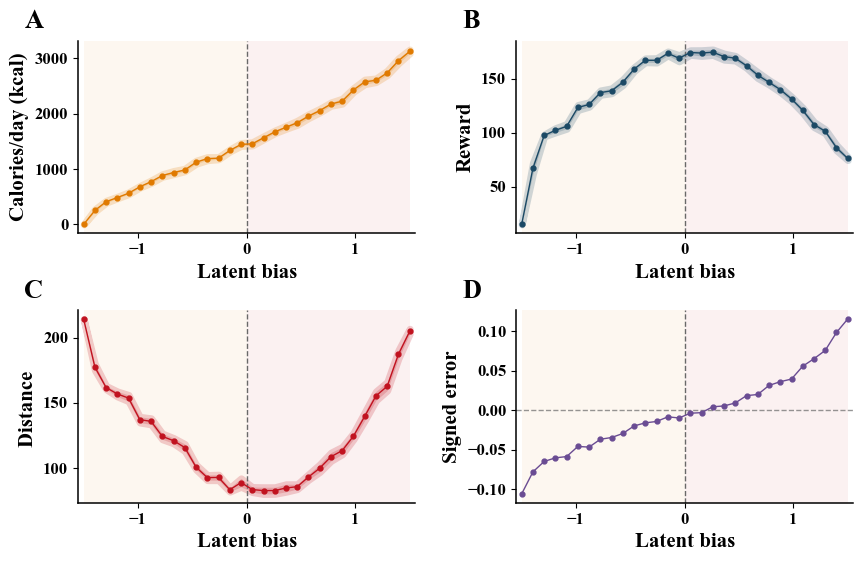

In [20]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE 3.2 — latent bias sweep
#  behaviour as latent bias goes from negative (under-eating) to positive
#  (over-eating): consumption, calories, reward, distance, signed error
#  data: results/plots_latent_ablation/bias_sweep.pkl  (nothing recomputed)
# ══════════════════════════════════════════════════════════════════════
plt.rcParams.update({"font.family":"serif","font.serif":["Times New Roman","DejaVu Serif"],
    "font.weight":"bold","axes.labelweight":"bold","axes.titleweight":"bold",
    "font.size":14,"axes.titlesize":15,"axes.labelsize":15,"xtick.labelsize":12,"ytick.labelsize":12,"axes.linewidth":1.1})

LAT_DIR=Path("results")/"plots_latent_ablation"
sw=pd.read_pickle(LAT_DIR/"bias_sweep.pkl").sort_values("value")
x=sw["value"].values

# (mean col, sem col or None, ylabel, colour)
DAYS_PER_EPISODE = 3   # convert per-episode totals to per-day
# (mean col, sem col or None, ylabel, colour, divisor)
PANELS=[
    ("calories_mean","calories_sem","Calories/day (kcal)","#e07a00", DAYS_PER_EPISODE),
    ("reward_mean","reward_sem","Reward","#1b4965", 1),
    ("distance_mean","distance_sem","Distance ","#c1121f", 1),
    ("signed_err_mean",None,"Signed error","#6a4c93", 1),
]
LETTERS=["A","B","C","D"]

fig,axes=plt.subplots(2,2,figsize=(10,6))
fig.subplots_adjust(
    wspace=0.3,   # horizontal spacing between columns
    hspace=0.4    # vertical spacing between rows
)
axes=axes.ravel()
for k,(mcol,scol,ylab,col,div) in enumerate(PANELS):
    print(scol)
    ax=axes[k]
    y=sw[mcol].values / div
    # under / over shading + baseline line
    ax.axvspan(x.min(),0,color=C_UNDER,alpha=0.06,lw=0)
    ax.axvspan(0,x.max(),color=C_OVER,alpha=0.06,lw=0)
    ax.axvline(0,color="dimgray",lw=1.0,ls="--")
    if mcol=="signed_err_mean":
        ax.axhline(0,color="dimgray",lw=1.0,ls="--",alpha=0.7)
    if scol is not None:
        se=sw[scol].values / div
        ax.fill_between(x,y-se,y+se,color=col,alpha=0.20,lw=5)
    ax.plot(x,y,color=col,lw=1.0,marker="o",ms=3.5)
    ax.set_xlabel("Latent bias")
    ax.set_ylabel(ylab)
    ax.set_xlim(x.min()-0.05,x.max()+0.05)
    ax.spines[["top","right"]].set_visible(False)
    ax.text(-0.16,1.16,LETTERS[k],transform=ax.transAxes,fontsize=19,fontweight="bold",va="top",ha="left")
# annotate under/over on the empty panel
# axes[-1].text(0.5,0.6,"Latent bias sweep",ha="center",fontsize=15,fontweight="bold")
# axes[-1].text(0.5,0.45,"bias $<$ 0  →  under-eating\nbias $>$ 0  →  over-eating",ha="center",fontsize=12)
# fig.tight_layout()
save_fig(fig, "fig4_ablation", "fig4_1_bias_sweep")
plt.show()


Conditions: {'Baseline': ('baseline', 0.0), 'Under-eating (b = -1.0)': ('bias=-1', -1.0), 'Over-eating (b = +1.0)': ('bias=+1.5', 1.5)}
Bias sweep: 30 values in [-1.50, +1.50]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig4_ablation/bias_sweep_condition.[png|pdf|svg|eps]


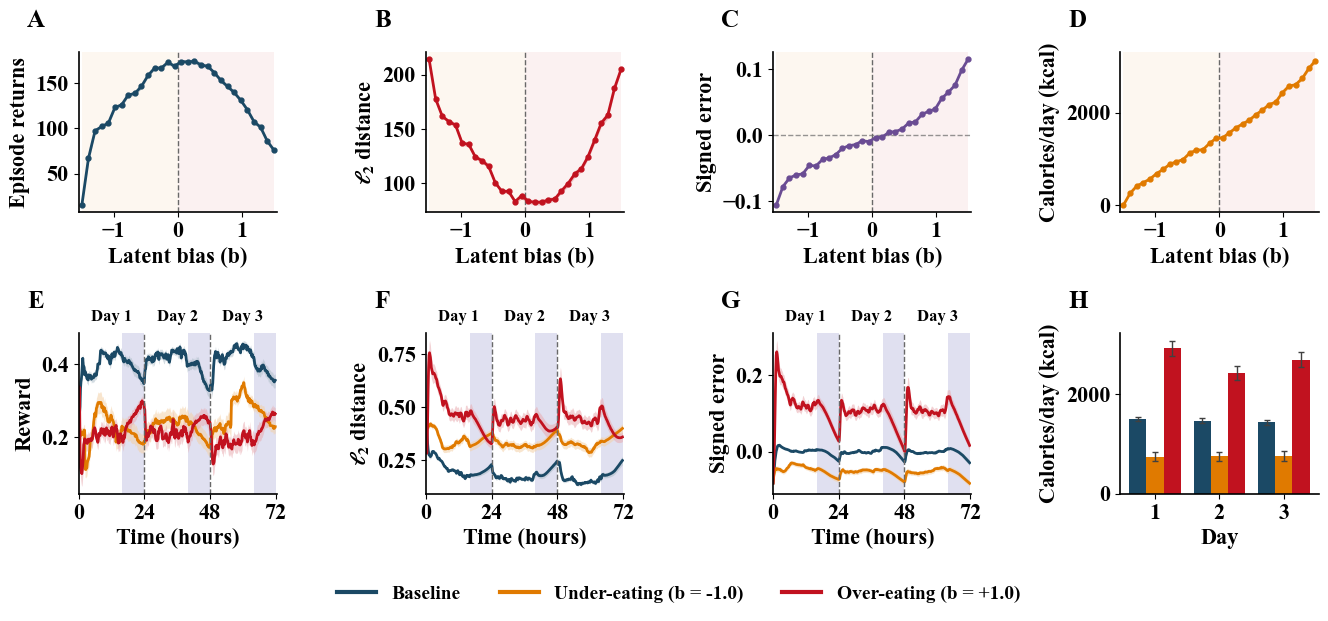

In [21]:
# ══════════════════════════════════════════════════════════════════════
#  MERGED FIGURE — latent bias sweep (top row) + condition overlay (bottom)
#  2 x 4 grid, self-contained: every input is re-read from disk here.
#    row 1 (A-D): behaviour vs latent bias
#                 (orange = under-eating side, red = over-eating side)
#                 <- results/plots_latent_ablation/bias_sweep.pkl
#    row 2 (E-H): baseline / under-eating / over-eating overlaid
#                 <- perstep_by_condition.pkl + conditions_capture.pkl
#  Columns are aligned by metric across both rows:
#      reward | l2 distance | signed error | calories/day
#  Conditions are discovered from the data by bias sign, so this is robust
#  to the bias magnitudes changing between runs.
#  rcParams are applied through a local rc_context and every helper lives
#  inside the function, so no other cell in the notebook is affected.
# ══════════════════════════════════════════════════════════════════════
MERGED4_RC = {
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    18,
    "axes.labelsize":    16,
    "xtick.labelsize":   16,
    "ytick.labelsize":   16,
    "legend.fontsize":   14,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "mathtext.default":  "bf",
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
}


def plot_bias_sweep_conditions_merged(
    lat_dir=Path("results") / "plots_latent_ablation",
    section="fig4_ablation",
    name="bias_sweep_condition",
):
    """2 x 4 merged figure: bias sweep (top) + condition overlay (bottom).

    Reads all of its own data. Depends only on the imports cell
    (`save_fig`, `C_NORMAL`, `C_UNDER`, `C_OVER`, `SLEEP_COLOR`).
    """
    import warnings
    from matplotlib.lines import Line2D

    lat_dir = Path(lat_dir)

    # ── data ────────────────────────────────────────────────────────────
    sweep       = pd.read_pickle(lat_dir / "bias_sweep.pkl").sort_values("value")
    perstep_all = pd.read_pickle(lat_dir / "perstep_by_condition.pkl")
    cc          = pd.read_pickle(lat_dir / "conditions_capture.pkl")
    runs, meta  = cc["runs"], cc["meta"]

    # ── local style / layout constants ──────────────────────────────────
    STEPS_PER_HOUR   = 6
    DAYS_PER_EPISODE = 3          # episode totals -> per-day
    BAND_LIGHTEN     = 0.65
    LINE_W           = 2.0
    LETTER_FS        = 18
    DAY_FS           = 12         # 15pt collides at this panel width
    LEGEND_FS        = 14
    SWEEP_SHADE      = 0.06       # under/over background tint, row 1

    def _lighten(color, amount):
        r, g, b = mcolors.to_rgb(color)
        return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

    def _letter(ax, s):
        ax.text(-0.26, 1.26, s, transform=ax.transAxes, fontsize=LETTER_FS,
                fontweight="bold", va="top", ha="left")

    # ── conditions, discovered by bias sign ─────────────────────────────
    cond_bias = (perstep_all[["condition", "bias"]]
                 .drop_duplicates().set_index("condition")["bias"])
    base = "baseline" if "baseline" in cond_bias.index else cond_bias.abs().idxmin()
    CASES = [                                    # (display name, condition key, colour)
        ("Baseline",     base,                C_NORMAL),
        ("Under-eating (b = -1.0)", cond_bias.idxmin(),  C_UNDER),  
        ("Over-eating (b = +1.0)",  cond_bias.idxmax(),  C_OVER),   
    ]

    T_EP        = int(perstep_all["step"].max()) + 1
    TOTAL_HOURS = T_EP / STEPS_PER_HOUR
    hours       = np.arange(T_EP) / STEPS_PER_HOUR
    HOUR_TICKS  = np.arange(0, TOTAL_HOURS + 1, 24)
    SLEEP_WINS  = meta["sleep_windows"]
    N_DAYS      = int(round(TOTAL_HOURS / 24))

    def _shade_sleep(ax):
        for ws, we in SLEEP_WINS:
            ax.axvspan(ws / STEPS_PER_HOUR, we / STEPS_PER_HOUR,
                       color=SLEEP_COLOR, lw=0, zorder=0)

    def _day_labels(ax):
        for d in range(N_DAYS):
            ax.text((d + 0.5) * 24, 1.05, f"Day {d+1}",
                    transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                    fontsize=DAY_FS, fontweight="bold")
        for d in range(1, N_DAYS):
            ax.axvline(d * 24, color="dimgray", ls="--", lw=1.0)

    # Columns are aligned by metric across the two rows:
    #   reward | l2 distance | signed error | calories/day
    # (mean col, sem col or None, y-label, colour, divisor) — row 1
    SWEEP_PANELS = [
        ("reward_mean",     "reward_sem",   "Episode returns",              "#1b4965", 1),
        ("distance_mean",   "distance_sem", r"$\ell_2$ distance",  "#c1121f", 1),
        ("signed_err_mean", None,           "Signed error",        "#6a4c93", 1),
        ("calories_mean",   "calories_sem", "Calories/day (kcal)", "#e07a00", DAYS_PER_EPISODE),
    ]
    # (per-step metric key, y-label) — row 2; 'cal' = grouped bars
    OVERLAY_PANELS = [
        ("rew",    "Reward"),
        ("dist",   r"$\ell_2$ distance"),
        ("signed", "Signed error"),
        ("cal",    "Calories/day (kcal)"),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(16, 6.5))
    fig.subplots_adjust(wspace=0.75, hspace=0.75, bottom=0.20)

    # ── ROW 1 — behaviour vs latent bias ────────────────────────────────
    xb = sweep["value"].values
    for ax, (mcol, scol, ylabel, color, div), letter in zip(
            axes[0], SWEEP_PANELS, ["A", "B", "C", "D"]):
        y = sweep[mcol].values / div
        ax.axvspan(xb.min(), 0, color=C_UNDER, alpha=SWEEP_SHADE, lw=0)
        ax.axvspan(0, xb.max(), color=C_OVER,  alpha=SWEEP_SHADE, lw=0)
        ax.axvline(0, color="dimgray", lw=1.0, ls="--")
        if mcol == "signed_err_mean":
            ax.axhline(0, color="dimgray", lw=1.0, ls="--", alpha=0.7)
        if scol is not None:
            se = sweep[scol].values / div
            ax.fill_between(xb, y - se, y + se, color=color, alpha=0.20, lw=0)
        ax.plot(xb, y, color=color, lw=LINE_W, marker="o", ms=3.5)
        ax.set_xlabel("Latent bias (b)")
        ax.set_ylabel(ylabel)
        ax.set_xlim(xb.min() - 0.05, xb.max() + 0.05)
        ax.spines[["top", "right"]].set_visible(False)
        _letter(ax, letter)

    # ── ROW 2 — the three conditions overlaid ───────────────────────────
    ts_axes = {k: axes[1, c] for c, (k, _) in enumerate(OVERLAY_PANELS) if k != "cal"}
    for ax in ts_axes.values():
        _shade_sleep(ax)

    for nice, key, color in CASES:
        sub = perstep_all[perstep_all.condition == key]
        for metric, ax in ts_axes.items():
            m  = sub[sub.metric == metric].sort_values("step")
            mu, se = m["mean"].values, m["sem"].values
            ax.fill_between(hours, mu - se, mu + se, color=_lighten(color, BAND_LIGHTEN),
                            lw=0, alpha=0.55, zorder=1)
            ax.plot(hours, mu, color=color, lw=LINE_W, zorder=2)

    for c, (key, ylabel) in enumerate(OVERLAY_PANELS):
        if key == "cal":
            continue
        ax = axes[1, c]
        # if key == "signed":
        #     ax.axhline(0, color="darkgrey", lw=0.9, ls="--")
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel(ylabel)
        ax.set_xlim(0, TOTAL_HOURS + 0.5)
        ax.set_xticks(HOUR_TICKS)
        ax.spines[["top", "right"]].set_visible(False)
        _day_labels(ax)

    # ── calories/day: grouped bars, one group per day ───────────────────
    c_cal  = [c for c, (k, _) in enumerate(OVERLAY_PANELS) if k == "cal"][0]
    ax_cal = axes[1, c_cal]
    bw, day_ref = 0.8 / len(CASES), None
    for j, (nice, key, color) in enumerate(CASES):
        run = runs.get(key)
        if run is None or "cal_per_day" not in run:
            continue
        cm  = np.asarray(run["cal_per_day"], dtype=float)     # (n_sims, n_days)
        xd  = np.arange(1, cm.shape[1] + 1); day_ref = xd
        cnt = np.sum(~np.isnan(cm), axis=0)
        dmean = np.nanmean(cm, axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dstd = np.nanstd(cm, axis=0, ddof=1)
        dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
        ax_cal.bar(xd + (j - (len(CASES) - 1) / 2) * bw, dmean, yerr=dsem, width=bw,
                   color=color, capsize=2, error_kw=dict(lw=1.0, ecolor="0.25"), zorder=2)
    if day_ref is not None:
        ax_cal.set_xticks(day_ref)
    ax_cal.set_xlabel("Day")
    ax_cal.set_ylabel(OVERLAY_PANELS[c_cal][1])
    ax_cal.spines[["top", "right"]].set_visible(False)

    for ax, letter in zip(axes[1], ["E", "F", "G", "H"]):
        _letter(ax, letter)

    # ── shared condition legend (bottom, applies to row 2) ──────────────
    handles = [Line2D([0], [0], color=color, lw=3, label=nice) for nice, _, color in CASES]
    fig.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 0.045),
               ncol=len(handles), frameon=False, fontsize=LEGEND_FS)

    print("Conditions:", {nice: (key, float(cond_bias[key])) for nice, key, _ in CASES})
    print(f"Bias sweep: {len(xb)} values in [{xb.min():+.2f}, {xb.max():+.2f}]")

    save_fig(fig, section, name)
    return fig


with plt.rc_context(MERGED4_RC):
    plot_bias_sweep_conditions_merged()
    plt.show()

# Figure 5 — TD-clip retrain
Loads the saved bundles (`td_clip_retrain_conditions.pkl` for the 3 conditions; `td_clip_plot_data.pkl` for the clip sweep) — no model/torch needed. **Fig 5.3 requires re-running `td_clip_retrain.ipynb`** so its pkl carries `rep_eat_steps` + `minmax`.

In [22]:
import os, glob, pickle, warnings
import matplotlib.pyplot as plt
import os, glob, json
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, LogNorm



FIG5_DIR  = os.path.join('plots', 'fig5_td_clip'); os.makedirs(FIG5_DIR, exist_ok=True)
COND_PKL  = 'results/plots_td_clip_retrain/td_clip_retrain_conditions.pkl'  # 3 conditions (reqs 1,2,3)
SWEEP_PKL = 'results/plots_retrain/td_clip_plot_data.pkl'                    # clip sweep   (reqs 4,5)
PEREP_PKL = 'results/plots_retrain/inference_per_episode.pkl'               # freshest per-episode inference

cond_data = pickle.load(open(COND_PKL, 'rb'))
RES       = cond_data['results']
sweep     = pickle.load(open(SWEEP_PKL, 'rb'))

# condition order for Figs 5.1-5.3
COND_ORDER = ['no clip'] + [l for l, _ in cond_data['conditions'] if l != 'no clip']
COND_ORDER = [l for l in COND_ORDER if l in RES]
# no clip = normal (blue); +clip -> under-eating (orange); -clip -> over-eating (red)
CLR = {l: (C_NORMAL if 'no clip' in l else (C_UNDER if '+' in l else C_OVER))
       for l in COND_ORDER}

def _sleepwins(a):
    w, ins, s = [], False, 0
    for t, v in enumerate(a):
        if not v and not ins: ins, s = True, t
        elif v and ins: ins = False; w.append((s, t))
    if ins: w.append((s, len(a)))
    return w

# ── Rebuild severity frames (Figs 5.4/5.5) from the FRESHEST per-episode data ──
# Prefers inference_per_episode.pkl over the (possibly older) frames baked into
# td_clip_plot_data.pkl, so Fig 5.4/5.5 reflects every del-lim you've inferred
# without needing to re-run the plots-notebook save cell.
AGG_METRICS = [('signed_dist', 'Signed distance'), ('food_items', 'Consumption (food items)'),
               ('return', 'Return'), ('distance', 'Distance (L2)'), ('calories', 'Total calories (kcal)')]

def _dl_label(dl):
    if dl is None or (isinstance(dl, float) and (dl == 0 or np.isnan(dl))):
        return 'no clip'
    return f'{"+" if dl > 0 else "-"}{abs(float(dl)):g}'

def _severity_frame(df_subset, noclip_df):
    parts = pd.concat([noclip_df, df_subset], ignore_index=True); recs = []
    for (dl, sev), g in parts.groupby(['limit_delta', 'severity'], dropna=False):
        rec = {'limit_delta': dl, 'severity': sev, 'label': _dl_label(dl),
               'n_episodes': len(g), 'n_seeds': int(g['seed'].nunique())}
        for key, _ in AGG_METRICS:
            rec[f'{key}_mean'] = g[key].mean()
            rec[f'{key}_sem']  = g[key].std(ddof=1) / np.sqrt(len(g)) if len(g) > 1 else 0.0
        recs.append(rec)
    fr = pd.DataFrame(recs); fr['is_noclip'] = fr['severity'] == 0
    return fr.sort_values(['is_noclip', 'severity'], ascending=[True, True]).reset_index(drop=True)

def _ntags(df):
    return df['tag'].nunique() if (df is not None and 'tag' in getattr(df, 'columns', [])) else -1

_pkl_pe   = sweep.get('per_ep_df')
_fresh_pe = pd.read_pickle(PEREP_PKL) if os.path.exists(PEREP_PKL) else None
per_ep    = _fresh_pe if (_fresh_pe is not None and _ntags(_fresh_pe) >= _ntags(_pkl_pe)) else _pkl_pe
_src      = PEREP_PKL if per_ep is _fresh_pe else SWEEP_PKL

if per_ep is not None and 'sign' in per_ep.columns:
    _nc = per_ep[per_ep['sign'] == 0]
    sweep['severity_pos'] = _severity_frame(per_ep[per_ep['sign'] > 0], _nc)
    sweep['severity_neg'] = _severity_frame(per_ep[per_ep['sign'] < 0], _nc)
    sweep['per_ep_df']    = per_ep
    print(f'Severity frames rebuilt from {os.path.basename(_src)}  ({_ntags(per_ep)} del-lim tags)')

print('Conditions loaded :', COND_ORDER)
print('Sweep frames       :', [k for k in ('severity_pos', 'severity_neg') if k in sweep])

# ── Freshness check vs the del-lim folders actually on disk ────────────────
_root = sweep.get('config', {}).get('RETRAIN_ROOT', 'results/retrain_500ep')
_disk = {p.split(os.sep)[-3]
         for p in glob.glob(os.path.join(_root, '*', 'checkpoints_retrain_*', 'retrain_info.json'))}
_have = set(per_ep['tag'].unique()) if (per_ep is not None and 'tag' in per_ep.columns) else set()
_missing = sorted(_disk - _have)
if _missing:
    print(f'\n[!] {len(_missing)} del-lim folder(s) on disk NOT in the inference data:')
    print('    ', _missing)
    print('    Fix: re-run the INFERENCE cell in td_clip_retrain_plots.ipynb (regenerates')
    print(f'         inference_per_episode.pkl), then re-run THIS load cell.')
else:
    print(f'\n[ok] inference data covers all {len(_disk)} del-lim folders under {_root}.')

Severity frames rebuilt from inference_per_episode.pkl  (34 del-lim tags)
Conditions loaded : ['no clip', '-severe (-0.0001)', '+severe (+1e-05)']
Sweep frames       : ['severity_pos', 'severity_neg']

[ok] inference data covers all 34 del-lim folders under results/retrain_500ep.


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_6288/1636906747.py:14: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  cond_data = pickle.load(open(COND_PKL, 'rb'))


### Fig 5.1: Retrain curves

15 negative + 18 positive del-lims, n=10-10 seeds, ckpt=ep300


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/retrain_curves_delim_sweep.[png|pdf|svg|eps]


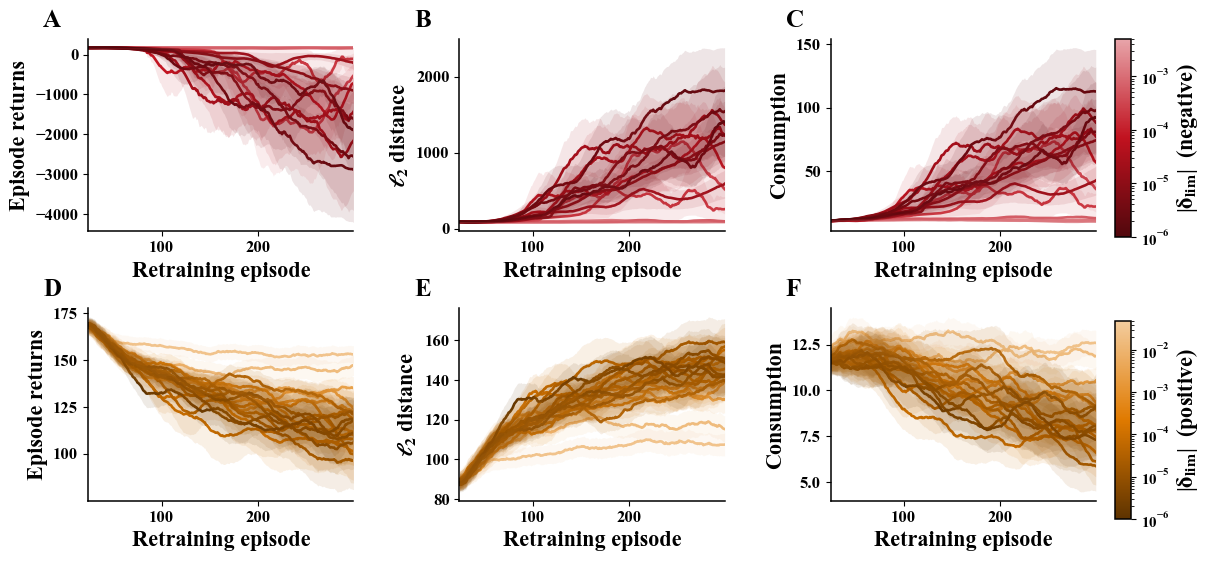

In [23]:
C_OVER   = "#c1121f"  
C_UNDER  = "#e07a00"


# ── config ────────────────────────────────────────────────────────────
RETRAIN_ROOT = Path('results') / 'retrain_500ep'   # sweep produced by td_clip_retrain_sweep.ipynb
CKPT         = 'ep300'        # which per-episode log to read ('ep300', 'ep500', 'last', ...)
ROLL_WINDOW  = 25             # rolling-mean window
MIN_SEEDS    = 10             # drop del-lims with fewer seeds than this
SHOW_NOCLIP  = False           # overlay the no-clip control (blue, C_NORMAL)

METRICS = [('reward', 'Episode returns'), ('distance', '$\ell_2$ distance'),
           ('consumption', 'Consumption')]


def _collect_runs(root, ckpt):
    runs = {}
    for info_path in glob.glob(str(Path(root) / '*' / 'checkpoints_retrain_*' / 'retrain_info.json')):
        with open(info_path) as f:
            info = json.load(f)
        log = Path(info_path).parent / f'ppo_agent_{ckpt}_log.npz'
        if not log.exists():
            continue
        dl = info.get('limit_delta')
        runs.setdefault(0.0 if dl is None else float(dl), []).append(log)
    return runs

def _mean_se(logs, key, w):
    """mean ± SE across seeds of the rolling-mean per-episode series."""
    arrs = [np.asarray(np.load(p)[key], float) for p in logs]
    T = min(len(a) for a in arrs)
    M = np.stack([a[:T] for a in arrs])                       # (n_seeds, T)
    mu = M.mean(0)
    se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(T)
    roll = lambda x: x if len(x) < w else np.convolve(x, np.ones(w) / w, mode='valid')
    mu_r, se_r = roll(mu), roll(se)
    return np.arange(T)[T - len(mu_r):], mu_r, se_r

runs = _collect_runs(RETRAIN_ROOT, CKPT)
runs = {dl: p for dl, p in runs.items() if len(p) >= MIN_SEEDS}
assert runs, f'No runs with >= {MIN_SEEDS} seeds under {RETRAIN_ROOT} (ckpt {CKPT}).'

neg = sorted([d for d in runs if d < 0], key=abs, reverse=True)   # mild -> severe
pos = sorted([d for d in runs if d > 0], key=abs, reverse=True)   # mild -> severe
print(f'{len(neg)} negative + {len(pos)} positive del-lims, '
      f'n={min(len(v) for v in runs.values())}-{max(len(v) for v in runs.values())} seeds, ckpt={CKPT}')

# ── 2. light -> dark ramps built from the canonical condition colours ──
def _ramp(base, name):
    """light tint of `base` -> `base` -> near-black shade of `base`."""
    b = np.array(mcolors.to_rgb(base))
    return LinearSegmentedColormap.from_list(
        name, [b + (1 - b) * 0.62, b, b * 0.42], N=256)

CMAP_NEG = _ramp(C_OVER,  'clip_neg')    # red    — negative del-lim (over-eating side)
CMAP_POS = _ramp(C_UNDER, 'clip_pos')    # orange — positive del-lim (under-eating side)

def _shades(dls, cmap):
    """Colour by |del-lim| on a log scale: large |clip| = light, small = dark."""
    a = np.log10(np.abs(dls))
    t = np.zeros_like(a) if np.ptp(a) == 0 else (a.max() - a) / (a.max() - a.min())
    return cmap(0.06 + 0.94 * t)

# ── 3. figure ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
fig.subplots_adjust(wspace=0.4, hspace=0.4, right=0.90)

ROWS = [(0, neg, CMAP_NEG, 'negative'),
        (1, pos, CMAP_POS, 'positive')]
LETTERS = np.array([['A', 'B', 'C'], ['D', 'E', 'F']])

for r, dls, cmap, row_title in ROWS:
    cols = _shades(np.array(dls), cmap)
    for dl, col in zip(dls, cols):
        for c, (key, ylab) in enumerate(METRICS):
            x, mu, se = _mean_se(runs[dl], key, ROLL_WINDOW)
            ax = axes[r, c]
            ax.fill_between(x, mu - se, mu + se, color=col, alpha=0.1, lw=0, zorder=2)
            ax.plot(x, mu, color=col, lw=1.9, zorder=1)
    if SHOW_NOCLIP and 0.0 in runs:
        for c, (key, ylab) in enumerate(METRICS):
            x, mu, se = _mean_se(runs[0.0], key, ROLL_WINDOW)
            ax = axes[r, c]
            ax.fill_between(x, mu - se, mu + se, color=C_NORMAL, alpha=0.20, lw=0, zorder=3)
            ax.plot(x, mu, color=C_NORMAL, lw=2.4, ls='--', zorder=4)
    for c, (key, ylab) in enumerate(METRICS):
        ax = axes[r, c]
        ax.set_xlabel('Retraining episode', fontsize = 16); ax.set_ylabel(ylab, fontsize = 16)
        ax.set_xlim(x.min(), x.max())
        ax.text(-0.17, 1.15, LETTERS[r, c], transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='left')
    # row colourbar: |del-lim|, log scale, inverted so dark = most severe
    lo, hi = float(np.min(np.abs(dls))), float(np.max(np.abs(dls)))
    cax = fig.add_axes([0.915, 0.55 - 0.47 * r, 0.012, 0.33])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=LogNorm(lo, hi), cmap=cmap.reversed()), cax=cax)
    cb.set_label('|$\\delta_{lim}$|  (' + row_title + ')', fontsize=16, fontweight='bold')
    cb.ax.tick_params(labelsize=11)

save_fig(fig, 'fig5_td_clip', 'retrain_curves_delim_sweep')
plt.show()

Positive del-lims available : ['+1e-06', '+2e-06', '+3e-06', '+5e-06', '+1e-05', '+2e-05', '+3e-05', '+5e-05', '+0.0001', '+0.0002', '+0.0003', '+0.0005', '+0.001', '+0.002', '+0.003', '+0.005', '+0.03', '+0.05']
Negative del-lims available : ['-1e-06', '-2e-06', '-3e-06', '-5e-06', '-1e-05', '-2e-05', '-3e-05', '-5e-05', '-0.0001', '-0.0003', '-0.0005', '-0.001', '-0.002', '-0.003', '-0.005']
  Negative $\delta_{\mathrm{lim}}$: plotting 8 δ_lim -> ['-1e-06', '-3e-06', '-1e-05', '-3e-05', '-0.0001', '-0.0005', '-0.002', '-0.005']
  Positive $\delta_{\mathrm{lim}}$: plotting 10 δ_lim -> ['+1e-06', '+3e-06', '+1e-05', '+3e-05', '+0.0001', '+0.0003', '+0.001', '+0.003', '+0.03', '+0.05']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_2_delim_sweep.[png|pdf|svg|eps]


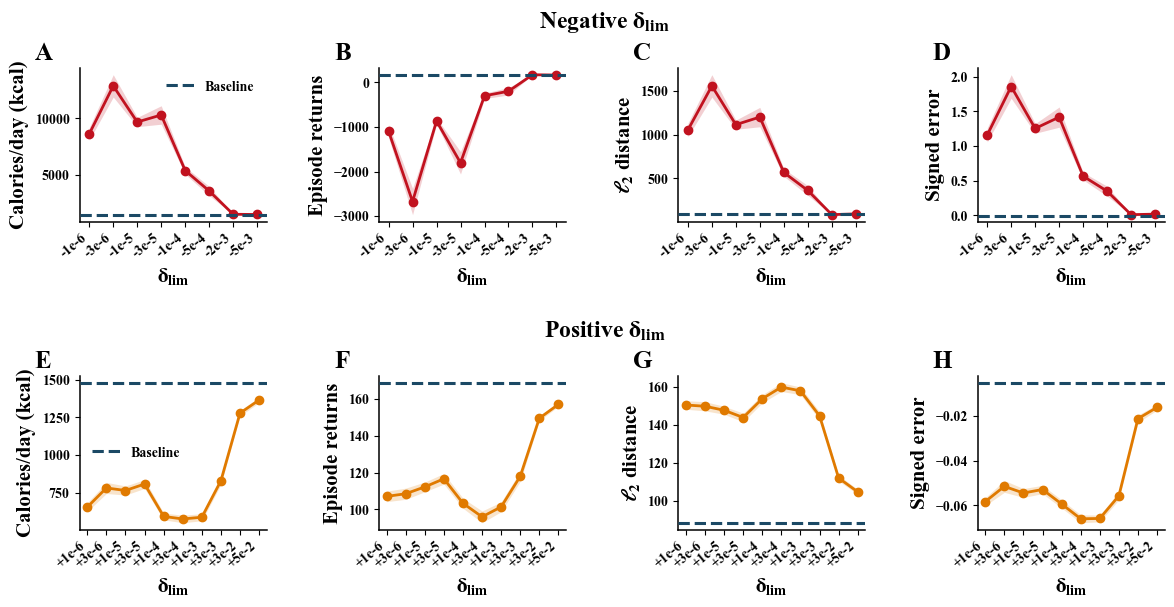

In [24]:
# ══════════════════════════════════════════════════════════════════════
#  Fig 5.2 — inference metrics vs δ_lim, both signs in ONE figure (2 x 4)
#  row 1 = negative δ_lim (red, over-eating side)
#  row 2 = positive δ_lim (orange, under-eating side)
#  no-clip baseline = dotted horizontal line (C_NORMAL) in every panel
#  data: `sweep` (results/plots_retrain/td_clip_plot_data.pkl)
# ══════════════════════════════════════════════════════════════════════
_pos_all = list(sweep['severity_pos'][~sweep['severity_pos']['is_noclip']]
                .sort_values('severity')['label'])
_neg_all = list(sweep['severity_neg'][~sweep['severity_neg']['is_noclip']]
                .sort_values('severity')['label'])
print('Positive del-lims available :', _pos_all)
print('Negative del-lims available :', _neg_all)

def _dlim_tick(v):
    """-1e-06 -> '-1e-6' ; 0.005 -> '+5e-3' ; 0.0003 -> '+3e-4'."""
    v = float(v)
    if v == 0:
        return '0'
    e = int(np.floor(np.log10(abs(v))))
    m = abs(v) / 10.0 ** e
    return f"{'+' if v > 0 else '-'}{round(m, 6):g}e{e}"


# ▼▼▼ WHICH δ_lim POINTS TO PLOT (per row) ▼▼▼
# 1) SELECT_*  : whitelist of labels (None/[] = all). Use the labels printed above.
# 2) SKIP_*    : drop these — accepts labels ('-1e-05') and/or integer indices
#                into the severity-sorted list (0 = smallest |clip|).
# 3) PLOT_EVERY: keep every Nth of what's left (1 = all, 2 = alternate).
#                First and last are always kept.
SELECT_POS = None
SELECT_NEG = None

SKIP_POS   = []            # e.g. ['+0.03', '+0.05']  or  [1, 3, 5]
SKIP_NEG   = []            # e.g. ['-0.00015']        or  [2, 4]

PLOT_EVERY = 2             # 1 = every δ_lim, 2 = alternate, 3 = every third
# ▲▲▲──────────────────────────────────────────────────────────────────▲▲▲

TICK_EVERY       = 1          # label every Nth *plotted* point (1 = all)
DAYS_PER_EPISODE = 3          # episode totals -> per-day (matches Fig 3.2)
DLIM = r'$\delta_{\mathrm{lim}}$'

# (key, ylabel, divisor)
M4 = [('calories',    'Calories/day (kcal)', DAYS_PER_EPISODE),
      ('return',      'Episode returns',     1),
      ('distance',    r'$\ell_2$ distance',  1),
      ('signed_dist', 'Signed error',        1)]

# ── font sizes for this figure ─────────────────────────────────────────
FS_LABEL, FS_TICK, FS_XTICK, FS_ROW = 15, 10, 10, 17

ROWS = [(sweep['severity_neg'], SELECT_NEG, SKIP_NEG, C_OVER,  f'Negative {DLIM}'),
        (sweep['severity_pos'], SELECT_POS, SKIP_POS, C_UNDER, f'Positive {DLIM}')]
LETTERS = np.array([['A', 'B', 'C', 'D'], ['E', 'F', 'G', 'H']])


def _row_points(fr, select, skip, every, tag):
    """(baseline frame, δ_lim points to plot) after select -> skip -> subsample."""
    base = fr[fr['is_noclip']]
    pts  = fr[~fr['is_noclip']].sort_values('severity').reset_index(drop=True)

    if select:                                        # 1) whitelist by label
        missing = sorted(set(select) - set(pts['label']))
        if missing:
            print(f'  [warn] {tag}: labels not found, ignored -> {missing}')
        pts = pts[pts['label'].isin(select)].reset_index(drop=True)

    if skip:                                          # 2) drop labels and/or indices
        drop_lbl = {s for s in skip if isinstance(s, str)}
        drop_idx = {int(s) for s in skip if not isinstance(s, str)}
        bad = sorted(drop_lbl - set(pts['label']))
        if bad:
            print(f'  [warn] {tag}: skip labels not found -> {bad}')
        keep = [i for i, lb in enumerate(pts['label'])
                if i not in drop_idx and lb not in drop_lbl]
        pts = pts.iloc[keep].reset_index(drop=True)

    if every and every > 1 and len(pts) > 2:          # 3) subsample, keep endpoints
        keep = sorted(set(range(0, len(pts), every)) | {len(pts) - 1})
        pts = pts.iloc[keep].reset_index(drop=True)

    if pts.empty:
        print(f'  [skip] {tag}: no δ_lim selected.')
        return None, None
    print(f'  {tag}: plotting {len(pts)} δ_lim -> {list(pts["label"])}')
    return base, pts


fig, axes = plt.subplots(2, len(M4), figsize=(14, 6))
fig.subplots_adjust(wspace=0.6, hspace=1.0, top=0.88)

for r, (fr, select, skip, color, row_lab) in enumerate(ROWS):
    base, pts = _row_points(fr, select, skip, PLOT_EVERY, row_lab)
    if pts is None:
        for ax in axes[r]:
            ax.axis('off')
        continue

    # x      = np.arange(len(pts))
    # labels = pts['label'].tolist()
    # shown  = [lb if i % TICK_EVERY == 0 else '' for i, lb in enumerate(labels)]
    x      = np.arange(len(pts))
    _vals  = (pts['limit_delta'] if 'limit_delta' in pts
              else pts['label'].astype(float))          # fallback
    labels = [_dlim_tick(v) for v in _vals]
    shown  = [lb if i % TICK_EVERY == 0 else '' for i, lb in enumerate(labels)]
    
    for c, (k, ylab, div) in enumerate(M4):
        ax  = axes[r, c]
        mu  = pts[f'{k}_mean'].values / div
        sem = pts[f'{k}_sem'].values / div

        ax.plot(x, mu, marker='o', ms=6, color=color, lw=2.0, zorder=2)
        ax.fill_between(x, mu - sem, mu + sem, color=color, alpha=0.20, lw=0)
        if len(base):                                  # no-clip baseline = dotted hline
            ax.axhline(base[f'{k}_mean'].iloc[0] / div, color=C_NORMAL, ls='--', lw=2.2,
                       zorder=3, label='Baseline')

        ax.set_xticks(x)
        ax.set_xticklabels(shown, rotation=40, ha='right', fontsize=FS_XTICK)
        ax.tick_params(axis='y', labelsize=FS_TICK)
        ax.set_xlabel(DLIM, fontsize=FS_LABEL)
        ax.set_ylabel(ylab, fontsize=FS_LABEL)
        ax.set_xlim(x.min() - 0.4, x.max() + 0.4)
        ax.text(-0.24, 1.16, LETTERS[r, c], transform=ax.transAxes,
                fontsize=18, fontweight='bold', va='top', ha='left')

    if len(base):                                      # one legend per row
        axes[r, 0].legend(fontsize=FS_TICK, frameon=False, loc='best')

    # ── row header text ────────────────────────────────────────────────
    y_top = max(ax.get_position().y1 for ax in axes[r])
    fig.text(0.5, y_top + 0.055, row_lab, ha='center', va='bottom',
             fontsize=FS_ROW, fontweight='bold', color='black')

save_fig(fig, 'fig5_td_clip', 'fig5_2_delim_sweep')
plt.show()

In [25]:
# ══════════════════════════════════════════════════════════════════════
#  Fig 5 baseline override — reuse the Fig 2 (normal-model) baseline as 'no clip'
#  ──────────────────────────────────────────────────────────────────────
#  The td-clip 'no clip' arm is a RETRAINED control (+500 ep). Here we
#  deliberately substitute the pristine normal-model inference
#  (results/plots_inference_normal) so the baseline shown in the INFERENCE
#  panels (Figs 5.2 / 5.3 / 5.6) matches Fig 2 exactly.  [temporary choice]
#
#  Metrics are rebuilt with the SAME formulas as td_clip_retrain.infer_pooled
#  (signed error & distance on the normalised nutrient state), so the baseline
#  is directly comparable to the +severe / -severe arms.
#  NOTE: Fig 5.1 (retraining curves) keeps the original 'no clip' training log,
#  because Fig 2 has no retraining curve to substitute.
# ══════════════════════════════════════════════════════════════════════
_NORM_DIR = Path("results") / "plots_inference_normal"

def _fig2_baseline_infer(pc, cycle_length=144):
    """Rebuild the Fig-5 'infer' schema from Fig 2's pooled_capture arrays."""
    phy   = np.asarray(pc["phy_nutrients"], float)          # (steps, n_nut) normalised
    rew   = np.asarray(pc["reward"], float)
    awake = np.asarray(pc["is_awake"]).astype(bool)
    asum  = np.asarray(pc["action_sum"], float)
    ei    = np.asarray(pc["episode_idx"])
    cal   = np.asarray(pc["calories_cumulative"], float)
    low   = np.asarray(pc["target_low"],  float)
    high  = np.asarray(pc["target_high"], float)
    tgt   = np.asarray(pc["target_norm"], float)
    names = list(pc["nutrient_names"])

    signed = (np.minimum(0.0, phy - low[None]) + np.maximum(0.0, phy - high[None])).mean(1)
    dist   = np.linalg.norm(phy - tgt[None], axis=1)
    ate    = (asum > 0) & awake

    eps = np.unique(ei)
    T   = int(min((ei == e).sum() for e in eps))
    st  = lambda v: np.stack([v[ei == e][:T] for e in eps])

    per_day = []
    for e in eps:
        ce  = cal[ei == e]
        inc = np.clip(np.diff(ce, prepend=0.0), 0.0, None)   # cumulative -> per-step kcal
        day = np.arange(len(ce)) // cycle_length
        per_day.append(np.array([inc[day == d].sum() for d in range(int(day.max()) + 1)]))
    Dmax   = max(len(v) for v in per_day)
    calmat = np.full((len(eps), Dmax), np.nan)
    for e, v in enumerate(per_day):
        calmat[e, :len(v)] = v

    ep_ret = np.array([rew[ei == e].sum() for e in eps])
    best   = int(eps[int(ep_ret.argmax())])
    bmask  = ei == best
    return {
        "reward_steps": st(rew), "dist_steps": st(dist), "signed_steps": st(signed),
        "cal_per_day":  calmat,
        "awake0": awake[ei == eps[0]][:T].astype(int), "T": T, "cycle_length": int(cycle_length),
        "rep_traj": phy[bmask][:T], "rep_awake": awake[bmask][:T].astype(int),
        "rep_z": np.asarray(pc["z_phy"], float)[bmask][:T],
        "rep_eat_steps": np.where(ate[bmask][:T])[0],
        "rep_return": float(ep_ret.max()), "rep_seed": int(pc.get("seed", -1)),
        "minmax": {nm: (float(pc["nutrient_minmax"][nm][0]),
                        float(pc["nutrient_minmax"][nm][1])) for nm in names},
        "names": names, "low": low, "high": high, "tgt": tgt,
    }

_bl = next((l for l in RES if "no clip" in l), None)
if _bl is not None:
    _pc = pd.read_pickle(_NORM_DIR / "pooled_capture.pkl")
    RES[_bl]["infer"] = _fig2_baseline_infer(_pc)
    _I = RES[_bl]["infer"]
    print(f"[Fig 5] baseline '{_bl}' inference overridden with Fig 2 normal-model data "
          f"({_I['reward_steps'].shape[0]} sims, T={_I['T']}, "
          f"kcal/day={np.nanmean(_I['cal_per_day'],0).round(0)}).")
else:
    print("[Fig 5] no 'no clip' condition found to override.")


def _rmean(x, w):
    x = np.asarray(x, float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode='valid')

def _shade_days(ax, wins, sph, nd, cyc):
    for ws, we in wins: ax.axvspan(ws / sph, we / sph, color=SLEEP_COLOR, lw=0, zorder=0)
    for d in range(1, nd + 1): ax.axvline(d * cyc / sph, color='dimgray', lw=1.0, ls='--')
def _msem(M):
    mu = M.mean(0); se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(M.shape[1])
    return mu, se
# # font conventions shared with Fig 2 / Fig 4 (day labels 15pt bold, letters 22pt)
DAY_LABEL_SIZE = 15
def _day_labels(ax, nd, cyc, sph):
    for d in range(nd):
        ax.text((d + 0.5) * cyc / sph, 1.04, f'Day {d+1}', transform=ax.get_xaxis_transform(),
                ha='center', va='bottom', fontsize=DAY_LABEL_SIZE, fontweight='bold')
def _panel_letter(ax, letter):
    ax.text(-0.16, 1.22, letter, transform=ax.transAxes, fontsize=PANEL_LABEL_SIZE,
            fontweight='bold', va='top', ha='left')

[Fig 5] baseline 'no clip' inference overridden with Fig 2 normal-model data (200 sims, T=432, kcal/day=[1565. 1388. 1428.]).


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/fig5_2_conditions_overlay.[png|pdf|svg|eps]


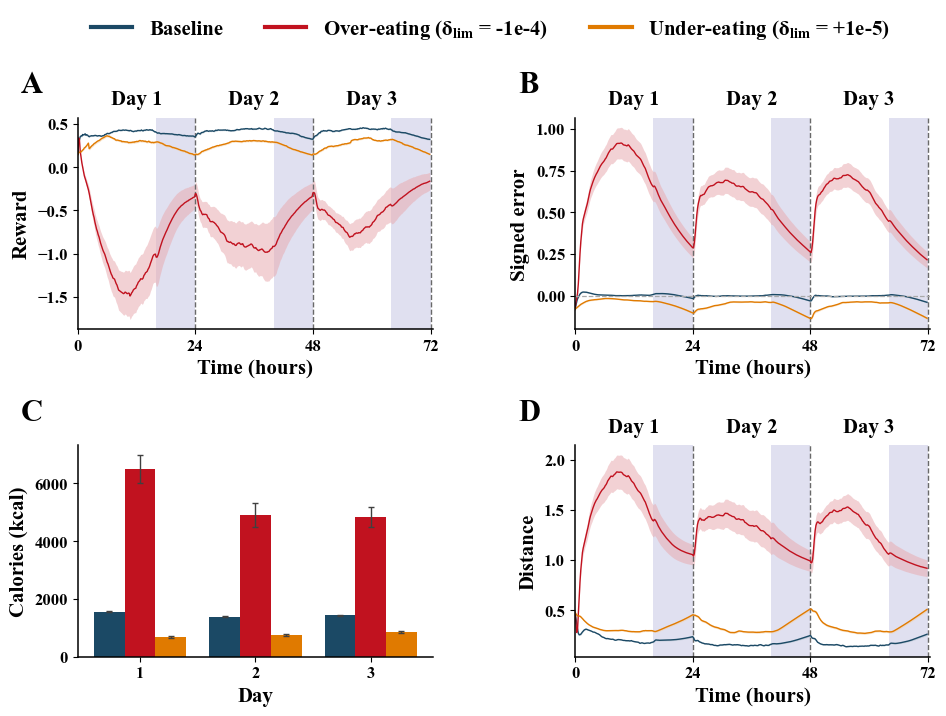

In [26]:
# ══════════════════════════════════════════════════════════════════════
#  Fig 5.3 (overlay) — all clip conditions on shared axes (2x2)
#  Reward · Signed error · Consumption (kcal/day) · Distance
#  Baseline / Under-eating (+δ_lim) / Over-eating (−δ_lim), shared legend.
#  Layout, band style, line width and legend match FIGURE 4 (overlay).
#  (reuses helpers _msem / _shade_days / _day_labels / _panel_letter above)
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

LEGEND_FS = 15                            # top condition-legend font size
_COND_DL  = dict(cond_data['conditions'])  # condition label -> δ_lim value


def _dlim_tick(v):
    """-1e-06 -> '-1e-6' ; 0.005 -> '+5e-3'."""
    v = float(v); e = int(np.floor(np.log10(abs(v))))
    return f"{'+' if v > 0 else '-'}{round(abs(v) / 10.0 ** e, 6):g}e{e}"


# def _nice(lbl):
#     """no clip -> 'Baseline'; +clip -> 'Under-eating (δ_lim = +5e-5)'; -clip -> 'Over-eating (...)'."""
#     if 'no clip' in lbl:
#         return 'Baseline'
#     name = 'Under-eating' if '+' in lbl else 'Over-eating'
#     dl   = _COND_DL.get(lbl)
#     if dl in (None, 0):                        # fall back to a number inside the label
#         m  = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', lbl)
#         dl = float(m.group()) if m else None
#     if dl in (None, 0):
#         return name
#     if '-' in lbl and dl > 0:                  # keep the sign consistent with the label
#         dl = -dl
#     return f'{name} ($\\delta_{{\\mathrm{{lim}}}}$ = {_dlim_tick(dl)})'
def _nice(lbl):
    """no clip -> 'Baseline'; +clip -> 'Under-eating (δ_lim = +5e-5)'; -clip -> 'Over-eating (...)'."""
    s = lbl.strip()
    if 'no clip' in s:
        return 'Baseline'

    neg  = s.lstrip().startswith('-')          # sign from the LEADING char only
    name = 'Over-eating' if neg else 'Under-eating'

    dl = _COND_DL.get(lbl)
    if dl in (None, 0):                        # fall back to a number inside the label
        m  = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
        dl = float(m.group()) if m else None
    if dl in (None, 0):
        return name

    dl = -abs(dl) if neg else abs(dl)          # trust the label's sign
    return f'{name} ($\\delta_{{\\mathrm{{lim}}}}$ = {_dlim_tick(dl)})'

fig, ((ax_r, ax_s), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(11, 7))
fig.subplots_adjust(wspace=0.4, hspace=0.55)

TS = [(ax_r, 'reward_steps', 'Reward', 'A'),
      (ax_s, 'signed_steps', 'Signed error', 'B'),
      (ax_d, 'dist_steps', 'Distance', 'D')]

conds = [l for l in COND_ORDER if RES.get(l, {}).get('infer') is not None]

# sleep shading from the first condition (shared day schedule)
_I0 = RES[conds[0]]['infer']
_T0, _cyc0 = _I0['T'], _I0['cycle_length']; _sph0 = _cyc0 / 24.0
_wins0 = _sleepwins(np.asarray(_I0['awake0']).astype(bool)); _nd0 = int(np.ceil(_T0 / _cyc0))
_HOUR_TICKS = np.arange(0, _nd0 * 24 + 1, 24)          # 0, 24, 48, 72 ...
for ax, _k, _yl, _lt in TS:
    _shade_days(ax, _wins0, _sph0, _nd0, _cyc0)

for lbl in conds:
    I = RES[lbl]['infer']; col = CLR[lbl]
    T = I['T']; sph = I['cycle_length'] / 24.0; hrs = np.arange(T) / sph
    for ax, key, ylabel, letter in TS:
        mu, se = _msem(np.asarray(I[key])[:, :T])
        ax.fill_between(hrs, mu - se, mu + se, color=lighten(col, 0.65),
                        lw=0, alpha=0.55, zorder=1)
        ax.plot(hrs, mu, color=col, lw=LINE_W, zorder=2, label=_nice(lbl))

for ax, key, ylabel, letter in TS:
    if key == 'signed_steps':
        ax.axhline(0, color='darkgrey', lw=0.9, ls='--')
    _day_labels(ax, _nd0, _cyc0, _sph0)
    ax.set_xlabel('Time (hours)'); ax.set_ylabel(ylabel)
    ax.set_xlim(0, _T0 / _sph0 + 0.5); ax.set_xticks(_HOUR_TICKS)
    _panel_letter(ax, letter)

# ── C. Consumption: grouped calories/day bars (one group per day) ───────
n_c = len(conds); bw = 0.8 / n_c; day_ref = None
for j, lbl in enumerate(conds):
    cm = np.asarray(RES[lbl]['infer']['cal_per_day'])
    xd = np.arange(1, cm.shape[1] + 1); day_ref = xd
    cnt = np.sum(~np.isnan(cm), 0); dmean = np.nanmean(cm, 0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore'); dstd = np.nanstd(cm, 0, ddof=1)
    dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
    off = (j - (n_c - 1) / 2) * bw
    ax_c.bar(xd + off, dmean, yerr=dsem, width=bw, color=CLR[lbl], capsize=2,
             error_kw=dict(lw=1.0, ecolor='0.25'), label=_nice(lbl), zorder=2)
if day_ref is not None:
    ax_c.set_xticks(day_ref)
ax_c.set_xlabel('Day'); ax_c.set_ylabel('Calories (kcal)')
_panel_letter(ax_c, 'C')

# ── shared condition legend ─────────────────────────────────────────────
handles = [Line2D([0], [0], color=CLR[lbl], lw=3, label=_nice(lbl)) for lbl in conds]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           ncol=len(conds), frameon=False, fontsize=LEGEND_FS)

save_fig(fig, 'fig5_td_clip', 'fig5_2_conditions_overlay')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/del_lim_expt_nutrient_trajectories.[png|pdf|svg|eps]


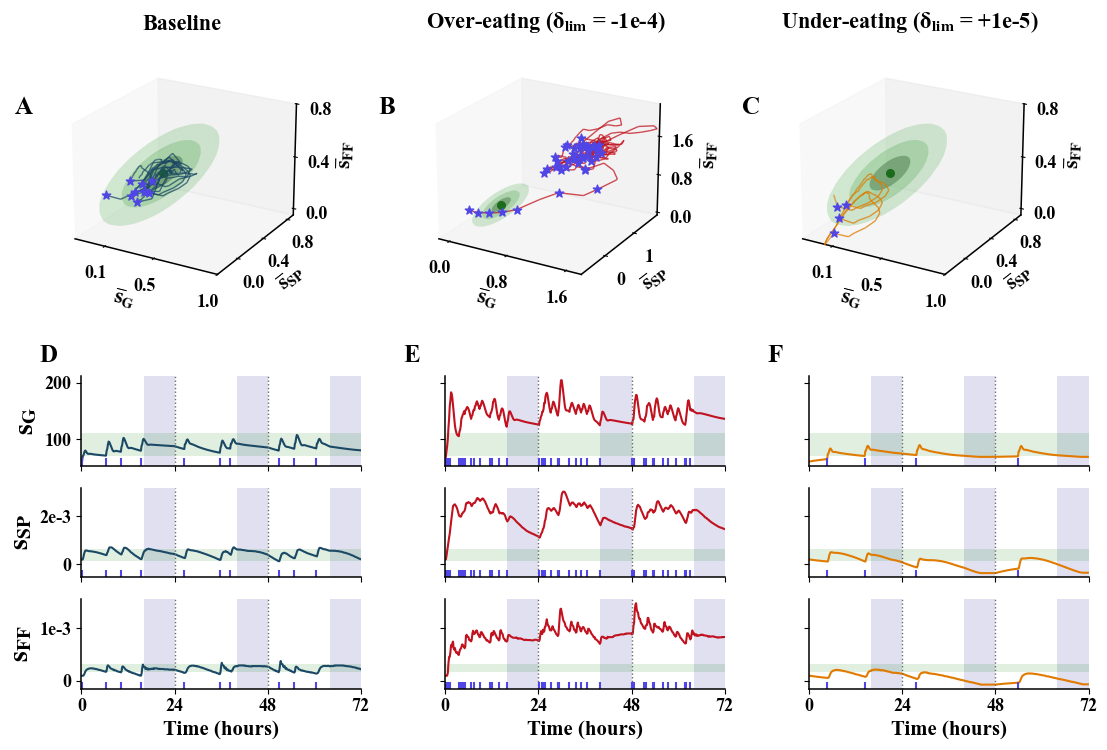

In [27]:
# ══════════════════════════════════════════════════════════════════════
#  Fig 5.3 — journal layout, columns = clip condition
#  row 1 (tall): 3D nutrient-space trajectory (A/B/C)
#  rows 2-4    : raw nutrient dynamics stacked (glucose / fatty acids / peptides),
#                shared y per nutrient across conditions; eaten events as thick
#                short ticks at each panel base; sci ticks for FA/peptides; D/E/F
#  Dimensions, gridspec and font sizes match fig4_3_ablation_journal_raw.
#  Needs rep_eat_steps + minmax in the capture (re-run td_clip_retrain.ipynb).
# ══════════════════════════════════════════════════════════════════════
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.colors as mcolors
from matplotlib.transforms import blended_transform_factory
from matplotlib.ticker import FuncFormatter, MaxNLocator

plt.rcParams.update({"font.family":"serif","font.serif":["Times New Roman","DejaVu Serif"],
    "font.weight":"bold","axes.labelweight":"bold","axes.titleweight":"bold",
    "font.size":14,"axes.titlesize":16,"axes.labelsize":15,"xtick.labelsize":13,"ytick.labelsize":13,"axes.linewidth":1.1})

LETTER_FS = 18
_COND_DL  = dict(cond_data['conditions'])          # condition label -> δ_lim value

# ── 3D helpers — same form as the Fig-4 journal cell (draw_target / plot_traj /
#    set3d). Parametrised because Fig 5 carries one target + awake mask per
#    condition, where Fig 4 closes over the single latent-ablation globals.
#    Named *_f5 so they do NOT overwrite the Fig-4 versions.
TARGET_SCALE = 2.5 * np.array([0.2, 2.4, 1.0])     # matches Fig-4 draw_target

def draw_target_f5(ax, low, high, ctr):
    """Nested translucent ellipsoids (light->dark toward centre) at the target."""
    c  = (low + high) / 2.0
    a0 = (high - low) / 2.0 * TARGET_SCALE         # outer semi-axes
    u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:16j]

    shells = [(1.00, "#32A432", 0.10),      # (scale, colour, alpha)  outer, light
              (0.66, "#3FA23F", 0.13),      # middle
              (0.34, "#083C08", 0.16)]      # inner, dark
    for sc, col, al in shells:
        a = a0 * sc
        xs = c[0] + a[0]*np.cos(u)*np.sin(v)
        ys = c[1] + a[1]*np.sin(u)*np.sin(v)
        zs = c[2] + a[2]*np.cos(v)
        ax.plot_surface(xs, ys, zs, color=col, alpha=al, linewidth=0, shade=False, zorder=0)
    ax.scatter([ctr[0]], [ctr[1]], [ctr[2]], color="#1B6B1B", s=30, marker="o", zorder=1)

def plot_traj_f5(ax, phy, color, eat_steps, awake, lw=1.0):
    """Solid uniform-colour 3D line (solid=awake, dashed=sleep) + food-eaten stars."""
    base = mcolors.to_rgb(color)
    pts  = phy.reshape(-1, 1, 3)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    styles = ["solid" if awake[i] else "dashed" for i in range(len(segs))]
    lc = Line3DCollection(segs, colors=base, linestyles=styles, linewidths=lw, zorder=5, alpha=0.75)
    ax.add_collection3d(lc)
    if len(eat_steps):
        ax.scatter(phy[eat_steps, 0], phy[eat_steps, 1], phy[eat_steps, 2],
                   marker="*", s=40, color=C_EAT, depthshade=False, zorder=6)
    ax.grid(False)

def set3d_f5(ax, limits=True):
    """limits=False -> let matplotlib autoscale (used where the trajectory
    overshoots the shared Fig-4 box, e.g. the over-eating condition)."""
    ax.set_xlabel(AXL[0]); ax.set_ylabel(AXL[1]); ax.set_zlabel(AXL[2])
    if limits:
        ax.set_xlim(-0.15, 1.0); ax.set_ylim(-0.3, 0.9); ax.set_zlim(-0.05, 0.8)
    else:
        ax.set_xlim(-0.15, 1.8)
    ax.view_init(elev=22, azim=-60); ax.grid(False)

# fixed ticks for the shared-box panels; autoscaled panels get <= N_TICKS_AUTO
FIXED_TICKS   = ([0.1, 0.5, 1.0], [0, 0.4, 0.8], [0, 0.4, 0.8])
N_TICKS_AUTO  = 4

def _dlim_tick(v):
    v = float(v); e = int(np.floor(np.log10(abs(v))))
    return f"{'+' if v > 0 else '-'}{round(abs(v) / 10.0 ** e, 6):g}e{e}"

def _nice(lbl):
    """no clip -> 'Baseline'; +clip -> 'Under-eating (δ_lim = +5e-5)'; -clip -> 'Over-eating (...)'."""
    s = lbl.strip()
    if 'no clip' in s:
        return 'Baseline'
    neg  = s.startswith('-')
    name = 'Over-eating' if neg else 'Under-eating'
    dl   = _COND_DL.get(lbl)
    if dl in (None, 0):
        m  = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', s)
        dl = float(m.group()) if m else None
    if dl in (None, 0):
        return name
    dl = -abs(dl) if neg else abs(dl)
    return f'{name} ($\\delta_{{\\mathrm{{lim}}}}$ = {_dlim_tick(dl)})'

AXL      = ['$\overline{s}_{G}$', '$\overline{s}_{SP}$', '$\overline{s}_{FF}$']             # 3D axis order = names order
NUT_ROWS = ['glucose', 'peptides', 'fatty_acids']          # raw-row order (matches Fig 4)
NUT_NICE = {'glucose': '$s_G$', 'fatty_acids': '$s_{FF}$', 'peptides': '$s_{SP}$'}
SCI_ROWS = {'fatty_acids', 'peptides'}
L3D      = ['A', 'B', 'C']; LBOT = ['D', 'E', 'F']

def sci_fmt(v, _):
    if v == 0: return '0'
    exp = int(np.floor(np.log10(abs(v)))); return f'{v/10**exp:g}e{exp}'

conds   = [l for l in COND_ORDER if 'infer' in RES.get(l, {})]
missing = [l for l in conds if 'rep_eat_steps' not in RES[l]['infer'] or 'minmax' not in RES[l]['infer']]
if missing:
    print('Fig 5.3 needs eat_steps + minmax — re-run td_clip_retrain.ipynb. Missing for:', missing)
else:
    nc = len(conds)
    fig = plt.figure(figsize=(13, 9))
    gs  = fig.add_gridspec(4, nc, height_ratios=[4, 1, 1, 1], hspace=0.14, wspace=0.30)
    row_ref, colx = {}, {}

    for k, lbl in enumerate(conds):
        I     = RES[lbl]['infer']; names = I['names']; col = mcolors.to_rgb(CLR[lbl])
        traj  = np.asarray(I['rep_traj']); eat = np.asarray(I['rep_eat_steps'])
        awake = np.asarray(I['rep_awake']).astype(bool)
        low, high, tgt = np.asarray(I['low']), np.asarray(I['high']), np.asarray(I['tgt'])
        mm    = I['minmax']
        cyc   = I['cycle_length']; sph = cyc / 24.0
        T     = traj.shape[0]; hours = np.arange(T) / sph; TOTAL_H = T / sph
        eat_h = eat / sph
        raw   = lambda nm, v: v * (mm[nm][1] - mm[nm][0]) + mm[nm][0]

        # ── row 1: 3D nutrient-space trajectory ────────────────────────
        # the over-eating arm overshoots the shared box -> autoscale that panel only
        shared_box = not lbl.strip().startswith('-')
        ax = fig.add_subplot(gs[0, k], projection='3d', computed_zorder=False)
        draw_target_f5(ax, low, high, tgt); plot_traj_f5(ax, traj, col, eat, awake)
        set3d_f5(ax, limits=shared_box)
        if shared_box:
            ax.set_xticks(FIXED_TICKS[0])
            ax.set_yticks(FIXED_TICKS[1])
            ax.set_zticks(FIXED_TICKS[2])
        else:
            for _axis in (ax.xaxis, ax.yaxis, ax.zaxis):
                _axis.set_major_locator(MaxNLocator(nbins=N_TICKS_AUTO - 1))
        ax.set_box_aspect(None, zoom=0.9)          # shrink content so right z-axis label fits
        _p = ax.get_position(); ax.set_position([_p.x0 - 0.03, _p.y0, _p.width, _p.height])
        ax.set_title(_nice(lbl), pad=0)
        ax.text2D(-0.1, 0.7, L3D[k], transform=ax.transAxes, fontsize=LETTER_FS,
                  fontweight='bold', va='bottom', ha='left')

        # ── rows 2-4: raw nutrient dynamics ────────────────────────────
        for ri, nm in enumerate(NUT_ROWS):
            if nm not in names:
                continue
            i  = names.index(nm)
            ax = fig.add_subplot(gs[1+ri, k], sharey=row_ref.get(nm), sharex=colx.get(k))
            if nm not in row_ref: row_ref[nm] = ax
            if k  not in colx:    colx[k]     = ax
            for ws, we in _sleepwins(awake):
                ax.axvspan(ws/sph, we/sph, color=SLEEP_COLOR, lw=0, zorder=0)
            ax.axhspan(raw(nm, low[i]), raw(nm, high[i]), color='green', alpha=0.12, lw=0)
            ax.plot(hours, raw(nm, traj[:, i]), color=col, lw=1.5)
            for x in range(24, int(TOTAL_H), 24):
                ax.axvline(x, color='dimgray', lw=1.0, ls=':')
            tr = blended_transform_factory(ax.transData, ax.transAxes)
            if len(eat):
                ax.vlines(eat_h, 0.0, 0.08, transform=tr, color=C_EAT, lw=1.5)
            ax.set_xlim(0, TOTAL_H + 0.1); ax.set_xticks([0, 24, 48, 72])
            ax.spines[['top', 'right']].set_visible(False)
            if ri < 2: plt.setp(ax.get_xticklabels(), visible=False)
            else:      ax.set_xlabel('Time (hours)')
            if k == 0:
                ax.set_ylabel(NUT_NICE[nm], fontsize = 20)
                if nm in SCI_ROWS: ax.yaxis.set_major_formatter(FuncFormatter(sci_fmt))
            else:
                plt.setp(ax.get_yticklabels(), visible=False)
            if ri == 0:
                ax.text(-0.15, 1.1, LBOT[k], transform=ax.transAxes, fontsize=LETTER_FS,
                        fontweight='bold', va='bottom', ha='left')

    save_fig(fig, 'fig5_td_clip', 'del_lim_expt_nutrient_trajectories')
    plt.show()

/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_6288/2513946219.py:66: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  cond_data = pickle.load(open(cond_pkl, "rb"))


Severity frames rebuilt from inference_per_episode.pkl (34 delta-lim tags)
Row 3 baseline 'no clip' <- Fig-2 normal model (200 sims)
  row 1: 8 delta_lim -> ['-1e-6', '-3e-6', '-1e-5', '-3e-5', '-1e-4', '-5e-4', '-2e-3', '-5e-3']
  row 2: 10 delta_lim -> ['+1e-6', '+3e-6', '+1e-5', '+3e-5', '+1e-4', '+3e-4', '+1e-3', '+3e-3', '+3e-2', '+5e-2']
Row 3 conditions: ['Baseline', 'Over-eating ($\\delta_{\\mathrm{lim}}$ = -1e-4)', 'Under-eating ($\\delta_{\\mathrm{lim}}$ = +1e-5)']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig5_td_clip/del_lim_sweep_condition.[png|pdf|svg|eps]


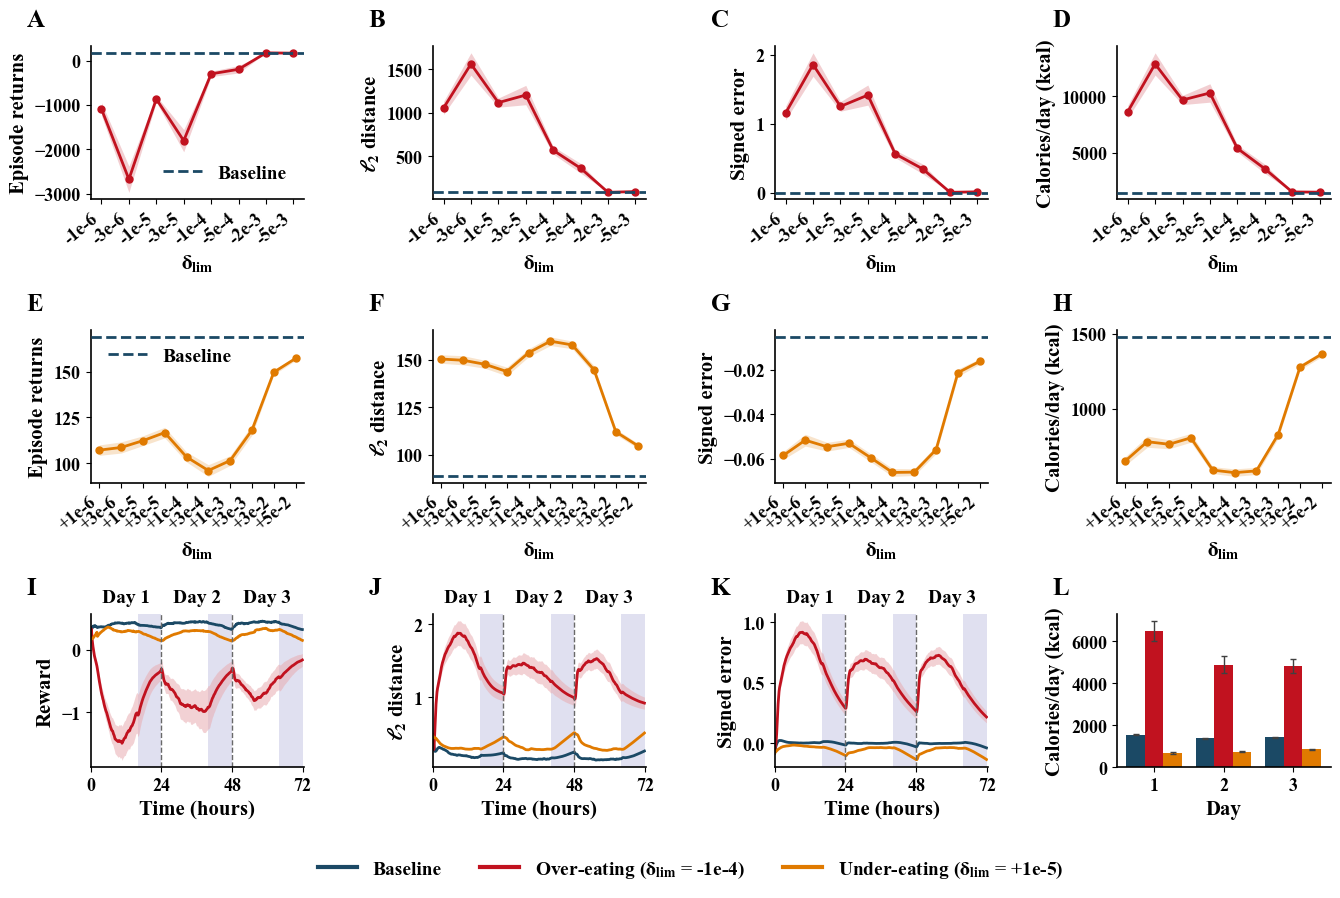

In [28]:
# ══════════════════════════════════════════════════════════════════════
#  MERGED FIGURE 5 — TD-clip: delta_lim sweep (rows 1-2) + condition overlay (row 3)
#  3 x 4 grid, self-contained: every input is re-read from disk here.
#    row 1 (A-D): inference metrics vs NEGATIVE delta_lim  (red, over-eating side)
#    row 2 (E-H): inference metrics vs POSITIVE delta_lim  (orange, under-eating)
#                 <- results/plots_retrain/{td_clip_plot_data,inference_per_episode}.pkl
#                    severity frames rebuilt from the per-episode file when it is
#                    present, exactly as the Fig-5 loader cell does
#    row 3 (I-L): baseline / under-eating / over-eating overlaid, per-step
#                 <- results/plots_td_clip_retrain/td_clip_retrain_conditions.pkl
#                    with the 'no clip' baseline overridden by the Fig-2 normal
#                    model (results/plots_inference_normal/pooled_capture.pkl)
#  Columns are aligned by metric across all three rows:
#      reward | l2 distance | signed error | calories/day
#  Rows 1-2 keep the Fig 5.2 selection config (PLOT_EVERY = 2).
#  rcParams are applied through a local rc_context and every helper lives
#  inside the function, so no other cell in the notebook is affected.
# ══════════════════════════════════════════════════════════════════════
MERGED5_RC = {
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":         16,
    "axes.titlesize":    18,
    "axes.labelsize":    15,
    "xtick.labelsize":   13,     # rows 1-2 carry rotated delta_lim labels
    "ytick.labelsize":   13,
    "legend.fontsize":   15,
    "axes.linewidth":    1.2,
    "lines.linewidth":   2.2,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "svg.fonttype":      "none",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "mathtext.default":  "bf",
    "axes.grid":         False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
}


def plot_td_clip_merged(
    sweep_pkl=Path("results") / "plots_retrain" / "td_clip_plot_data.pkl",
    perep_pkl=Path("results") / "plots_retrain" / "inference_per_episode.pkl",
    cond_pkl=Path("results") / "plots_td_clip_retrain" / "td_clip_retrain_conditions.pkl",
    norm_dir=Path("results") / "plots_inference_normal",
    plot_every=2,                 # 1 = every delta_lim, 2 = alternate (Fig 5.2 config)
    fig2_baseline=True,           # use the Fig-2 normal model as the 'no clip' baseline
    section="fig5_td_clip",
    name="del_lim_sweep_condition",
):
    """3 x 4 merged figure: delta_lim sweep (rows 1-2) + condition overlay (row 3).

    Reads all of its own data. Depends only on the imports cell
    (`save_fig`, `C_NORMAL`, `C_UNDER`, `C_OVER`, `SLEEP_COLOR`).
    """
    import pickle, warnings
    from matplotlib.lines import Line2D

    # ── data ────────────────────────────────────────────────────────────
    sweep     = pickle.load(open(sweep_pkl, "rb"))
    cond_data = pickle.load(open(cond_pkl, "rb"))
    RES       = {k: dict(v) for k, v in cond_data["results"].items()}   # local copy
    COND_DL   = dict(cond_data["conditions"])                           # label -> delta_lim

    # ── local style / layout constants ──────────────────────────────────
    DAYS_PER_EPISODE = 3          # episode totals -> per-day
    BAND_LIGHTEN     = 0.65
    LINE_W           = 2.0
    SWEEP_LW, SWEEP_MS = 2.0, 5.0
    LETTER_FS        = 18
    DAY_FS           = 14         # 15pt collides at this panel width
    ROW_FS           = 16
    LEGEND_FS        = 14
    XTICK_ROT        = 40
    DLIM = r"$\delta_{\mathrm{lim}}$"

    def _lighten(color, amount):
        r, g, b = mcolors.to_rgb(color)
        return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

    def _letter(ax, s):
        ax.text(-0.30, 1.24, s, transform=ax.transAxes, fontsize=LETTER_FS,
                fontweight="bold", va="top", ha="left")

    def _dlim_tick(v):
        """-1e-06 -> '-1e-6' ; 0.005 -> '+5e-3' ; 0 -> '0'."""
        v = float(v)
        if v == 0:
            return "0"
        e = int(np.floor(np.log10(abs(v))))
        return f"{'+' if v > 0 else '-'}{round(abs(v) / 10.0 ** e, 6):g}e{e}"

    # ── severity frames: prefer the freshest per-episode inference ──────
    AGG = ["signed_dist", "food_items", "return", "distance", "calories"]

    def _severity_frame(df_subset, noclip_df):
        parts, recs = pd.concat([noclip_df, df_subset], ignore_index=True), []
        for (dl, sev), g in parts.groupby(["limit_delta", "severity"], dropna=False):
            rec = {"limit_delta": dl, "severity": sev, "n_episodes": len(g)}
            for key in AGG:
                rec[f"{key}_mean"] = g[key].mean()
                rec[f"{key}_sem"]  = (g[key].std(ddof=1) / np.sqrt(len(g))) if len(g) > 1 else 0.0
            recs.append(rec)
        fr = pd.DataFrame(recs)
        fr["is_noclip"] = fr["severity"] == 0
        return fr.sort_values(["is_noclip", "severity"]).reset_index(drop=True)

    per_ep = pd.read_pickle(perep_pkl) if Path(perep_pkl).exists() else sweep.get("per_ep_df")
    if per_ep is not None and "sign" in per_ep.columns:
        nc  = per_ep[per_ep["sign"] == 0]
        neg = _severity_frame(per_ep[per_ep["sign"] < 0], nc)
        pos = _severity_frame(per_ep[per_ep["sign"] > 0], nc)
        print(f"Severity frames rebuilt from {Path(perep_pkl).name} "
              f"({per_ep['tag'].nunique()} delta-lim tags)")
    else:
        neg, pos = sweep["severity_neg"], sweep["severity_pos"]
        print("Severity frames taken from td_clip_plot_data.pkl")

    def _points(fr, every):
        """(baseline row, delta_lim points) after severity sort + subsampling."""
        base = fr[fr["is_noclip"]]
        pts  = fr[~fr["is_noclip"]].sort_values("severity").reset_index(drop=True)
        if every and every > 1 and len(pts) > 2:
            keep = sorted(set(range(0, len(pts), every)) | {len(pts) - 1})
            pts  = pts.iloc[keep].reset_index(drop=True)
        return base, pts

    # ── Fig-2 normal model as the 'no clip' baseline (row 3) ────────────
    def _fig2_baseline_infer(pc, cycle_length=144):
        phy   = np.asarray(pc["phy_nutrients"], float)
        rew   = np.asarray(pc["reward"], float)
        awake = np.asarray(pc["is_awake"]).astype(bool)
        ei    = np.asarray(pc["episode_idx"])
        cal   = np.asarray(pc["calories_cumulative"], float)
        low   = np.asarray(pc["target_low"],  float)
        high  = np.asarray(pc["target_high"], float)
        tgt   = np.asarray(pc["target_norm"], float)

        signed = (np.minimum(0.0, phy - low[None]) + np.maximum(0.0, phy - high[None])).mean(1)
        dist   = np.linalg.norm(phy - tgt[None], axis=1)

        eps = np.unique(ei)
        T   = int(min((ei == e).sum() for e in eps))
        st  = lambda v: np.stack([v[ei == e][:T] for e in eps])

        per_day = []
        for e in eps:
            ce  = cal[ei == e]
            inc = np.clip(np.diff(ce, prepend=0.0), 0.0, None)
            day = np.arange(len(ce)) // cycle_length
            per_day.append(np.array([inc[day == d].sum() for d in range(int(day.max()) + 1)]))
        calmat = np.full((len(eps), max(len(v) for v in per_day)), np.nan)
        for e, v in enumerate(per_day):
            calmat[e, :len(v)] = v

        return {"reward_steps": st(rew), "dist_steps": st(dist), "signed_steps": st(signed),
                "cal_per_day": calmat, "awake0": awake[ei == eps[0]][:T].astype(int),
                "T": T, "cycle_length": int(cycle_length)}

    bl = next((l for l in RES if "no clip" in l), None)
    if fig2_baseline and bl is not None:
        RES[bl] = dict(RES[bl])
        RES[bl]["infer"] = _fig2_baseline_infer(pd.read_pickle(norm_dir / "pooled_capture.pkl"))
        print(f"Row 3 baseline '{bl}' <- Fig-2 normal model "
              f"({RES[bl]['infer']['reward_steps'].shape[0]} sims)")

    # ── condition order + colours: no clip = blue, +clip = orange, -clip = red
    conds = [l for l in (["no clip"] + [l for l, _ in cond_data["conditions"] if l != "no clip"])
             if RES.get(l, {}).get("infer") is not None]
    CLR   = {l: (C_NORMAL if "no clip" in l else (C_UNDER if l.strip().startswith("+") else C_OVER))
             for l in conds}

    def _nice(lbl):
        s = lbl.strip()
        if "no clip" in s:
            return "Baseline"
        neg_ = s.startswith("-")
        nm   = "Over-eating" if neg_ else "Under-eating"
        dl   = COND_DL.get(lbl)
        if dl in (None, 0):
            m  = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
            dl = float(m.group()) if m else None
        if dl in (None, 0):
            return nm
        return f"{nm} ({DLIM} = {_dlim_tick(-abs(dl) if neg_ else abs(dl))})"

    def _sleepwins(a):
        w, ins, s = [], False, 0
        for t, v in enumerate(a):
            if not v and not ins: ins, s = True, t
            elif v and ins:       ins = False; w.append((s, t))
        if ins: w.append((s, len(a)))
        return w

    # ── column layout: reward | l2 distance | signed error | calories/day
    # rows 1-2 (sweep): (per-episode key, y-label, divisor)
    SWEEP_COLS = [("return",      "Episode returns",     1),
                  ("distance",    r"$\ell_2$ distance",  1),
                  ("signed_dist", "Signed error",        1),
                  ("calories",    "Calories/day (kcal)", DAYS_PER_EPISODE)]
    # row 3 (overlay): (per-step key or 'cal', y-label)
    OVERLAY_COLS = [("reward_steps", "Reward"),
                    ("dist_steps",   r"$\ell_2$ distance"),
                    ("signed_steps", "Signed error"),
                    ("cal",          "Calories/day (kcal)")]

    fig, axes = plt.subplots(3, 4, figsize=(16, 9.75))
    fig.subplots_adjust(wspace=0.6, hspace=0.85, bottom=0.14)

    # ── ROWS 1-2 — inference metrics vs delta_lim ───────────────────────
    LETTERS = np.array([["A", "B", "C", "D"], ["E", "F", "G", "H"]])
    for r, (fr, color, row_lab) in enumerate([(neg, C_OVER,  f"Negative {DLIM}"),
                                              (pos, C_UNDER, f"Positive {DLIM}")]):
        base, pts = _points(fr, plot_every)
        xs     = np.arange(len(pts))
        labels = [_dlim_tick(v) for v in pts["limit_delta"]]
        print(f"  row {r+1}: {len(pts)} delta_lim -> {labels}")

        for c, (key, ylabel, div) in enumerate(SWEEP_COLS):
            ax  = axes[r, c]
            mu  = pts[f"{key}_mean"].values / div
            sem = pts[f"{key}_sem"].values / div
            ax.plot(xs, mu, marker="o", ms=SWEEP_MS, color=color, lw=SWEEP_LW, zorder=2)
            ax.fill_between(xs, mu - sem, mu + sem, color=color, alpha=0.20, lw=0)
            if len(base):
                ax.axhline(base[f"{key}_mean"].iloc[0] / div, color=C_NORMAL,
                           ls="--", lw=2.0, zorder=3, label="Baseline")
            ax.set_xticks(xs)
            ax.set_xticklabels(labels, rotation=XTICK_ROT, ha="right")
            ax.set_xlim(xs.min() - 0.4, xs.max() + 0.4)
            ax.set_xlabel(DLIM)
            ax.set_ylabel(ylabel)
            ax.spines[["top", "right"]].set_visible(False)
            _letter(ax, LETTERS[r, c])
        if len(base):
            axes[r, 0].legend(fontsize=LEGEND_FS, frameon=False, loc="best")

        # header sits above the panel letters (which stick out to y1 + 0.24*height)
        # y_top = max(ax.get_position().y1 + 0.26 * ax.get_position().height for ax in axes[r])
        # fig.text(0.5, y_top + 0.006, row_lab, ha="center", va="bottom",
        #          fontsize=ROW_FS, fontweight="bold")

    # ── ROW 3 — the three clip conditions overlaid ──────────────────────
    I0    = RES[conds[0]]["infer"]
    T0    = I0["T"]; cyc0 = I0["cycle_length"]; sph0 = cyc0 / 24.0
    wins0 = _sleepwins(np.asarray(I0["awake0"]).astype(bool))
    n_d0  = int(np.ceil(T0 / cyc0))
    hrs   = np.arange(T0) / sph0
    HOUR_TICKS = np.arange(0, n_d0 * 24 + 1, 24)

    ts_axes = {k: axes[2, c] for c, (k, _) in enumerate(OVERLAY_COLS) if k != "cal"}
    for ax in ts_axes.values():
        for ws, we in wins0:
            ax.axvspan(ws / sph0, we / sph0, color=SLEEP_COLOR, lw=0, zorder=0)

    for lbl in conds:
        I, col = RES[lbl]["infer"], CLR[lbl]
        T = min(I["T"], T0)
        for key, ax in ts_axes.items():
            M  = np.asarray(I[key])[:, :T]
            mu = M.mean(0)
            se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(T)
            ax.fill_between(hrs[:T], mu - se, mu + se, color=_lighten(col, BAND_LIGHTEN),
                            lw=0, alpha=0.55, zorder=1)
            ax.plot(hrs[:T], mu, color=col, lw=LINE_W, zorder=2)

    for c, (key, ylabel) in enumerate(OVERLAY_COLS):
        if key == "cal":
            continue
        ax = axes[2, c]
        # if key == "signed_steps":
        #     ax.axhline(0, color="darkgrey", lw=0.9, ls="--")
        for d in range(n_d0):
            ax.text((d + 0.5) * 24, 1.05, f"Day {d+1}", transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=DAY_FS, fontweight="bold")
        for d in range(1, n_d0):
            ax.axvline(d * 24, color="dimgray", ls="--", lw=1.0)
        ax.set_xlabel("Time (hours)")
        ax.set_ylabel(ylabel)
        ax.set_xlim(0, T0 / sph0 + 0.5)
        ax.set_xticks(HOUR_TICKS)
        ax.spines[["top", "right"]].set_visible(False)

    # ── calories/day: grouped bars, one group per day ───────────────────
    c_cal  = [c for c, (k, _) in enumerate(OVERLAY_COLS) if k == "cal"][0]
    ax_cal = axes[2, c_cal]
    bw, day_ref = 0.8 / len(conds), None
    for j, lbl in enumerate(conds):
        cm  = np.asarray(RES[lbl]["infer"]["cal_per_day"], dtype=float)
        xd  = np.arange(1, cm.shape[1] + 1); day_ref = xd
        cnt = np.sum(~np.isnan(cm), axis=0)
        dmean = np.nanmean(cm, axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dstd = np.nanstd(cm, axis=0, ddof=1)
        dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
        ax_cal.bar(xd + (j - (len(conds) - 1) / 2) * bw, dmean, yerr=dsem, width=bw,
                   color=CLR[lbl], capsize=2, error_kw=dict(lw=1.0, ecolor="0.25"), zorder=2)
    if day_ref is not None:
        ax_cal.set_xticks(day_ref)
    ax_cal.set_xlabel("Day")
    ax_cal.set_ylabel(OVERLAY_COLS[c_cal][1])
    ax_cal.spines[["top", "right"]].set_visible(False)

    for ax, letter in zip(axes[2], ["I", "J", "K", "L"]):
        _letter(ax, letter)

    # ── shared condition legend (bottom, applies to row 3) ──────────────
    handles = [Line2D([0], [0], color=CLR[l], lw=3, label=_nice(l)) for l in conds]
    fig.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 0.035),
               ncol=len(handles), frameon=False, fontsize=LEGEND_FS)

    print("Row 3 conditions:", [_nice(l) for l in conds])

    save_fig(fig, section, name)
    return fig


with plt.rc_context(MERGED5_RC):
    plot_td_clip_merged()
    plt.show()

# Figure 2.3 — Meal timing across all inference episodes

Uses the pooled eating mask in `results/plots_inference_normal/pooled_capture.pkl`
(seed 0, best checkpoint, all 200 inference episodes) — nothing is recomputed.

Each day is 144 steps = 96 awake (16 h at 6 steps/h) + 48 asleep; only the awake
block is plotted, so the x-axis is **hours since wake (0-16 h)**.

- **A-C** raster: one row per inference episode, one dot per eating event,
  coloured by the meal's order within that day (1st / 2nd / 3rd / 4th / 5th+).
- **D-F** stacked 30-min histograms of the same events, shared y-axis.


/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_6288/2625986277.py:38: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  pc   = pickle.load(open(INF_DIR / "pooled_capture.pkl", "rb"))


200 episodes | 2139 eating events | 3.56 meals/day | max 7 meals in a day


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


saved fig2_normal_inference/meal_timing_pooled.[png|pdf|svg|eps]


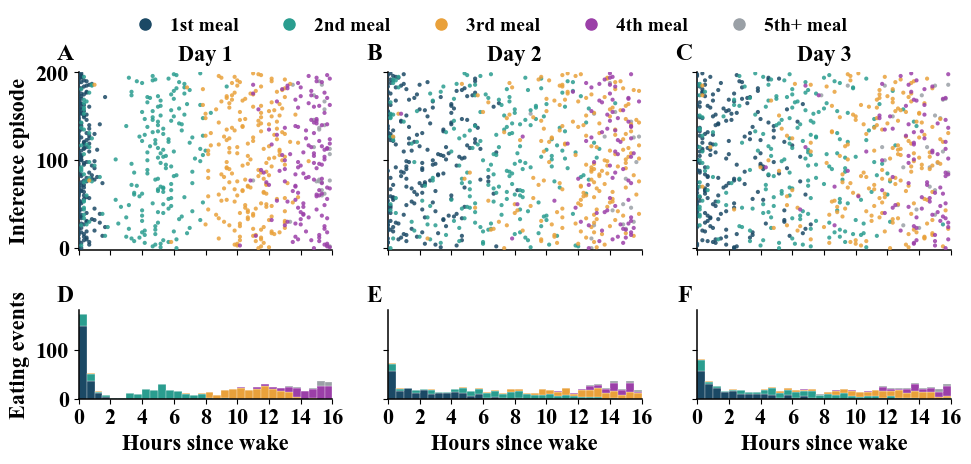

1st meal: n= 600  median  0.58 h  IQR [0.17, 2.33]
2nd meal: n= 600  median  5.50 h  IQR [3.50, 7.71]
3rd meal: n= 566  median 11.50 h  IQR [9.67, 13.00]
4th meal: n= 303  median 14.17 h  IQR [13.33, 15.17]


In [29]:
# ══════════════════════════════════════════════════════════════════════
#  FIGURE — meal timing across all inference episodes (normal model)
#  When does the agent eat, within each awake day?
#    row 1 (A-C): raster/scatter — one row per inference episode,
#                 x = hour since wake (0-16 h), colour = meal order in day
#    row 2 (D-F): distribution of meal times per meal ordinal (stacked hist)
#  Self-contained: everything is re-read from disk here.
#    <- results/plots_inference_normal/pooled_capture.pkl
#  Nothing is recomputed from the model; `ate` is the per-step eating mask
#  pooled over the N_INFERENCE episodes (seed 0, best checkpoint).
# ══════════════════════════════════════════════════════════════════════
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

INF_DIR   = Path("results") / "plots_inference_normal"
PLOTS_DIR = Path("plots") / "plots_inference"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── experiment geometry ────────────────────────────────────────────────
STEPS_PER_HOUR  = 6              # 96 awake steps / 16 h
AWAKE_H         = 16             # awake hours per day
AWAKE_STEPS     = AWAKE_H * STEPS_PER_HOUR   # 96
STEPS_PER_DAY   = 144            # 96 awake + 48 asleep
N_DAYS          = 3

# ── meal-ordinal colours (1st .. 4th meal, then "5th+") ────────────────
MEAL_COLORS = ["#1b4965",   # 1st — deep blue
               "#2a9d8f",   # 2nd — teal
               "#e9a13b",   # 3rd — amber
               "#9b3fa8"]   # 4th — purple
LATE_COLOR  = "#9aa0a6"     # 5th and beyond — grey
MEAL_LABELS = ["1st meal", "2nd meal", "3rd meal", "4th meal", "5th+ meal"]

# ── load pooled eating mask ────────────────────────────────────────────
pc   = pickle.load(open(INF_DIR / "pooled_capture.pkl", "rb"))
ate  = np.asarray(pc["ate"]).astype(bool)
n_ep = int(np.asarray(pc["n_inference"]))
A    = ate.reshape(n_ep, N_DAYS * STEPS_PER_DAY)      # (episodes, 432)

# sanity: no eating during the sleep block of any day
_sleep = sum(A[:, d * STEPS_PER_DAY + AWAKE_STEPS:(d + 1) * STEPS_PER_DAY].sum()
             for d in range(N_DAYS))
assert _sleep == 0, f"{_sleep} eating events fall inside a sleep window"

# ── build a tidy table: (day, episode, hour-since-wake, meal ordinal) ──
recs = {d: {"ep": [], "hour": [], "rank": []} for d in range(N_DAYS)}
for d in range(N_DAYS):
    block = A[:, d * STEPS_PER_DAY: d * STEPS_PER_DAY + AWAKE_STEPS]
    for e in range(n_ep):
        steps = np.flatnonzero(block[e])              # already time-ordered
        recs[d]["ep"].extend([e] * len(steps))
        recs[d]["hour"].extend(steps / STEPS_PER_HOUR)
        recs[d]["rank"].extend(np.arange(1, len(steps) + 1))
    for k in recs[d]:
        recs[d][k] = np.asarray(recs[d][k])

_all_ranks = np.concatenate([recs[d]["rank"] for d in range(N_DAYS)])
print(f"{n_ep} episodes | {A.sum()} eating events | "
      f"{A.sum() / (n_ep * N_DAYS):.2f} meals/day | max {_all_ranks.max()} meals in a day")


def _rank_color(r):
    return MEAL_COLORS[r - 1] if r <= 4 else LATE_COLOR


# ══════════════════════════════════════════════════════════════════════
#  figure
# ══════════════════════════════════════════════════════════════════════
with plt.rc_context({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "Nimbus Roman No9 L", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size":        16,
    "axes.titlesize":   16,
    "axes.labelsize":   16,
    "xtick.labelsize":  16,
    "ytick.labelsize":  16,
    "axes.linewidth":   1.1,
    "axes.spines.top":  False,
    "axes.spines.right": False,
}):
    fig, axes = plt.subplots(2, N_DAYS, figsize=(10, 4.6),
                             sharex=True, height_ratios=[2.0, 1.0])
    BINS = np.arange(0, AWAKE_H + 0.5, 0.5)           # 30-min bins

    for d in range(N_DAYS):
        ax_s, ax_h = axes[0, d], axes[1, d]
        hour, ep, rank = recs[d]["hour"], recs[d]["ep"], recs[d]["rank"]

        # ── row 1: raster over episodes ────────────────────────────────
        for r in range(1, 5):
            m = rank == r
            ax_s.scatter(hour[m], ep[m], s=9, color=MEAL_COLORS[r - 1],
                         edgecolors="none", alpha=0.85, zorder=3)
        m = rank >= 5
        ax_s.scatter(hour[m], ep[m], s=9, color=LATE_COLOR,
                     edgecolors="none", alpha=0.85, zorder=2)

        ax_s.set_xlim(0, AWAKE_H)
        ax_s.set_ylim(-2, n_ep + 1)
        ax_s.set_title(f"Day {d + 1}", pad=8)
        if d == 0:
            ax_s.set_ylabel("Inference episode")
        else:
            ax_s.tick_params(labelleft=False)

        # ── row 2: meal-time distribution, stacked by ordinal ──────────
        stack = [hour[rank == r] for r in range(1, 5)] + [hour[rank >= 5]]
        cols  = MEAL_COLORS + [LATE_COLOR]
        ax_h.hist(stack, bins=BINS, stacked=True, color=cols,
                  edgecolor="white", linewidth=0.2)
        ax_h.set_xlabel("Hours since wake")
        ax_h.set_xticks(np.arange(0, AWAKE_H + 1, 2))
        if d == 0:
            ax_h.set_ylabel("Eating events")
        else:
            ax_h.tick_params(labelleft=False)

    # shared y-limit on the histogram row
    hmax = max(ax.get_ylim()[1] for ax in axes[1])
    for ax in axes[1]:
        ax.set_ylim(0, hmax)

    # panel letters
    for ax, L in zip(axes.ravel(), "ABCDEF"):
        ax.text(-0.02, 1.04, L, transform=ax.transAxes,
                fontsize=17, fontweight="bold", ha="right", va="bottom")

    handles = [Line2D([0], [0], marker="o", linestyle="None", markersize=8,
                      color=c, label=l)
               for c, l in zip(MEAL_COLORS + [LATE_COLOR], MEAL_LABELS)]
    fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False,
               bbox_to_anchor=(0.5, 1.04), fontsize=14,
               handletextpad=0.3, columnspacing=1.6)

    fig.tight_layout()
    save_fig(fig, "fig2_normal_inference", "meal_timing_pooled")
    plt.show()

# ── median meal time per ordinal (printed summary) ─────────────────────
for r in range(1, 5):
    h = np.concatenate([recs[d]["hour"][recs[d]["rank"] == r] for d in range(N_DAYS)])
    print(f"{MEAL_LABELS[r - 1]}: n={len(h):4d}  median {np.median(h):5.2f} h  "
          f"IQR [{np.percentile(h, 25):.2f}, {np.percentile(h, 75):.2f}]")
